# EDA for Card Transdata

*link: https://www.kaggle.com/datasets/elakiyasekar/card-transdata/data*

In [84]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['figure.dpi'] = 300

In [85]:
df = pd.read_csv("../../card_transdata.csv")

## Первичный обзор датасета

In [86]:
print(f"Размер датасета: {df.shape}")
df

Размер датасета: (1000000, 8)


,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...
999995,2.207101,0.112651,1.626798,1.0,1.0,0.0,0.0,0.0
999996,19.872726,2.683904,2.778303,1.0,1.0,0.0,0.0,0.0
999997,2.914857,1.472687,0.218075,1.0,1.0,0.0,1.0,0.0
999998,4.258729,0.242023,0.475822,1.0,0.0,0.0,1.0,0.0


### Описание типов

In [87]:
pd.DataFrame({
    "Feature": df.columns,
    "Dtype": df.dtypes
})

,Feature,Dtype
distance_from_home,distance_from_home,float64
distance_from_last_transaction,distance_from_last_transaction,float64
ratio_to_median_purchase_price,ratio_to_median_purchase_price,float64
repeat_retailer,repeat_retailer,float64
used_chip,used_chip,float64
used_pin_number,used_pin_number,float64
online_order,online_order,float64
fraud,fraud,float64


### Количество пропусков

In [88]:
df.isnull().sum()

distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         0
used_pin_number                   0
online_order                      0
fraud                             0
dtype: int64

### Статистика по каждому столбцу

In [89]:
print(df.describe())

       distance_from_home  distance_from_last_transaction  \
count      1000000.000000                  1000000.000000   
mean            26.628792                        5.036519   
std             65.390784                       25.843093   
min              0.004874                        0.000118   
25%              3.878008                        0.296671   
50%              9.967760                        0.998650   
75%             25.743985                        3.355748   
max          10632.723672                    11851.104565   

       ratio_to_median_purchase_price  repeat_retailer       used_chip  \
count                  1000000.000000   1000000.000000  1000000.000000   
mean                         1.824182         0.881536        0.350399   
std                          2.799589         0.323157        0.477095   
min                          0.004399         0.000000        0.000000   
25%                          0.475673         1.000000        0.000000   
50%   

In [95]:
fraud_col = df["fraud"].to_numpy()

non_fraud_arr = fraud_col[fraud_col == 0]
fraud_arr = fraud_col[fraud_col == 1]
fraud_ratio = df["fraud"].mean() * 100

print(
    f"Количество не мошеннических транзакций: {len(non_fraud_arr)}, количество мошеннических транзакций: {len(fraud_arr)}")
print(f"Доля мошеннических транзакций: {fraud_ratio:.2f}%")
print(f"Распределение классов: {df['fraud'].value_counts()}")

Количество не мошеннических транзакций: 912597, количество мошеннических транзакций: 87403
Доля мошеннических транзакций: 8.74%
Распределение классов: fraud
0.0    912597
1.0     87403
Name: count, dtype: int64


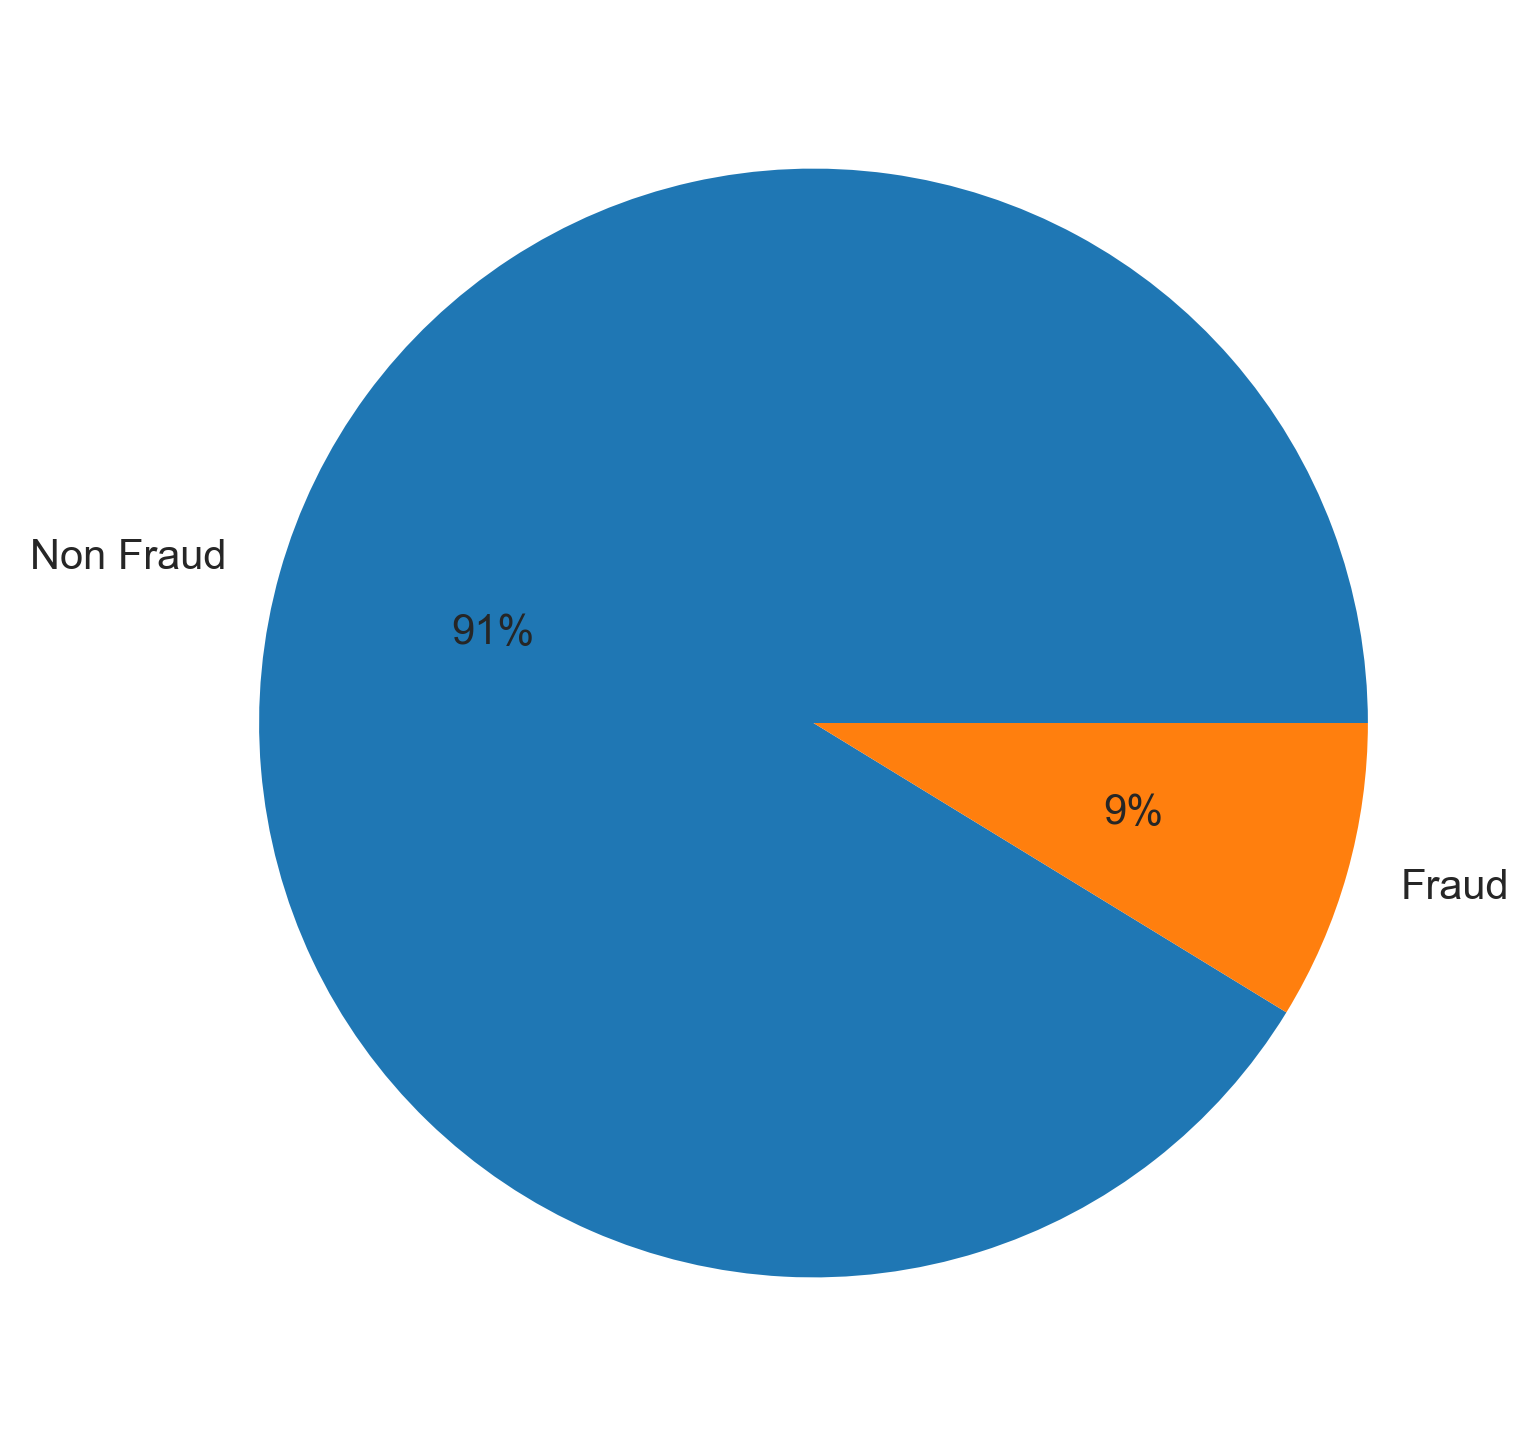

In [91]:
colors = sns.color_palette()[0:4]

plt.pie([len(non_fraud_arr), len(fraud_arr)], labels=["Non Fraud", "Fraud"], colors=colors, autopct='%.0f%%')
plt.show()

In [92]:
df.groupby("fraud")[
    [
        "distance_from_home",
        "distance_from_last_transaction",
        "ratio_to_median_purchase_price"
    ]
].mean()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price
fraud,,,
0.0,22.832976,4.301391,1.423642
1.0,66.261876,12.712185,6.006323


## Анализ признаков

### Матрица корреляций

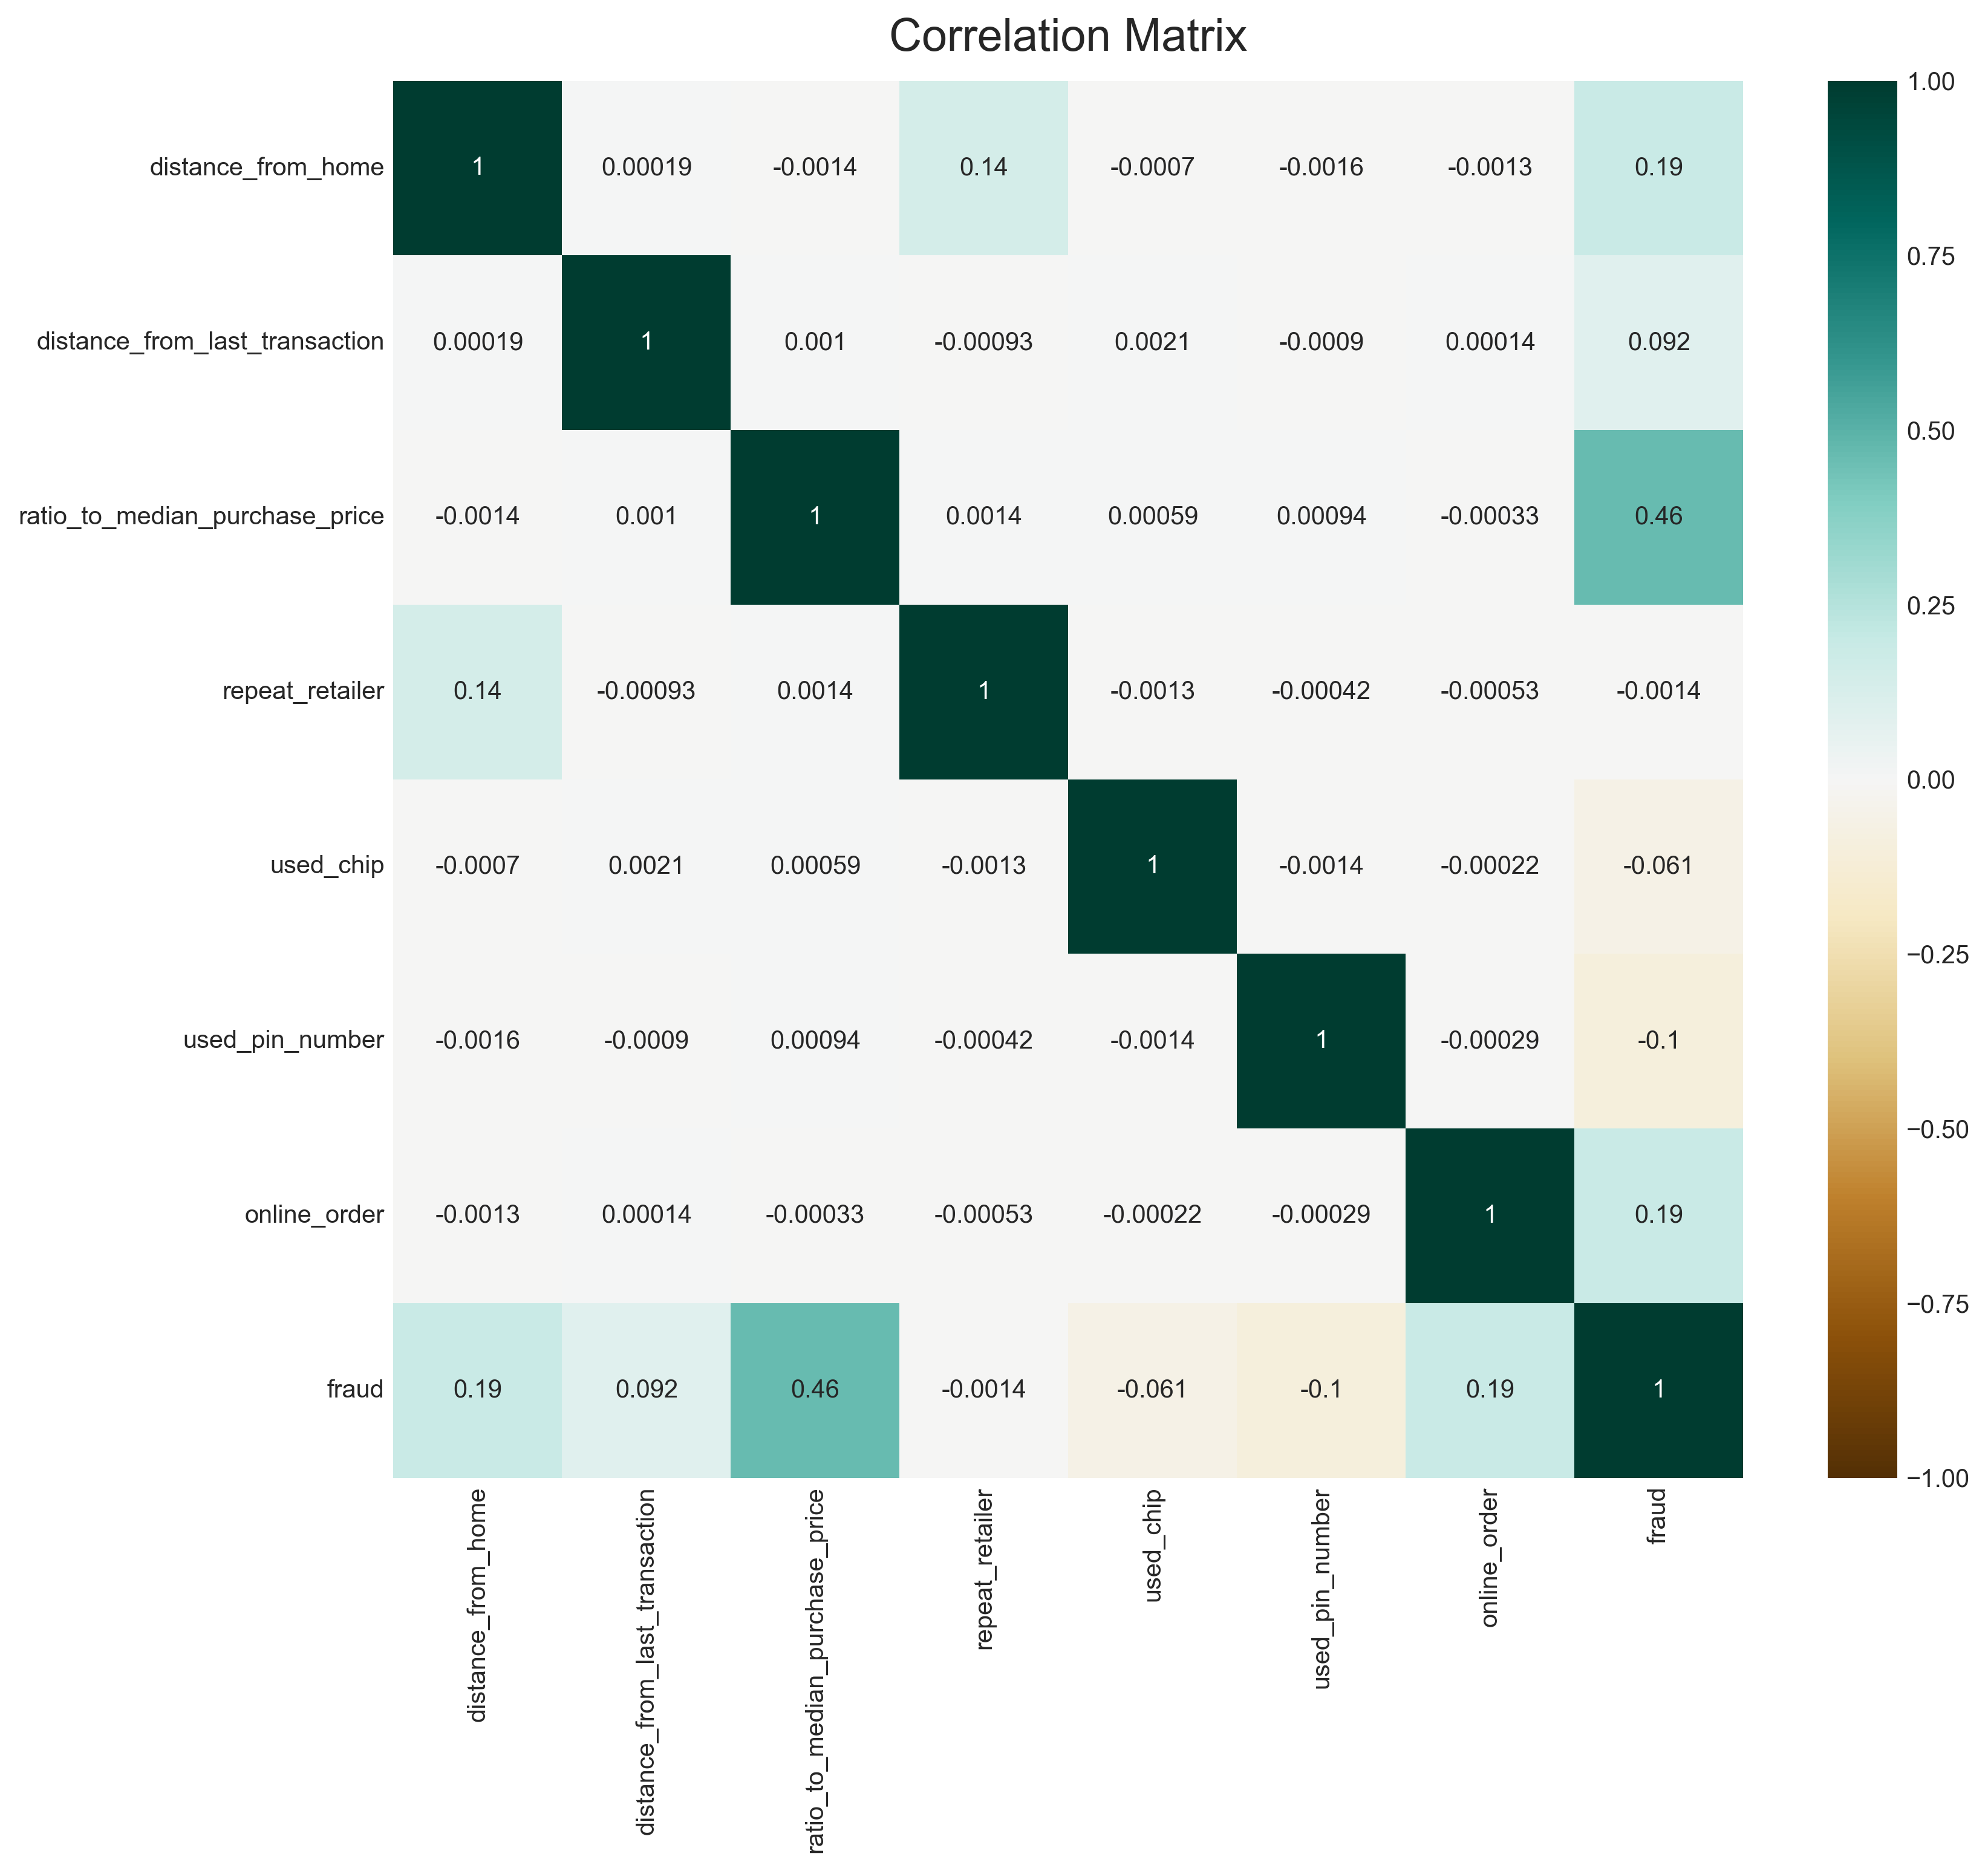

In [93]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), cmap='BrBG', vmin=-1, vmax=1, annot=True)
plt.title("Correlation Matrix", fontdict={'fontsize': 18}, pad=12)
plt.show()

Наиболее сильная линейная зависимость с целевой переменной fraud наблюдается у признака
ratio_to_median_purchase_price (≈0.46), что указывает на важность аномального размера покупки относительно типичного
поведения пользователя. Однако низкие значения корреляции не исключают информативность признаков из-за возможной
нелинейной зависимости.

### Распределение РАССТОЯНИЯ ОТ ДОМА

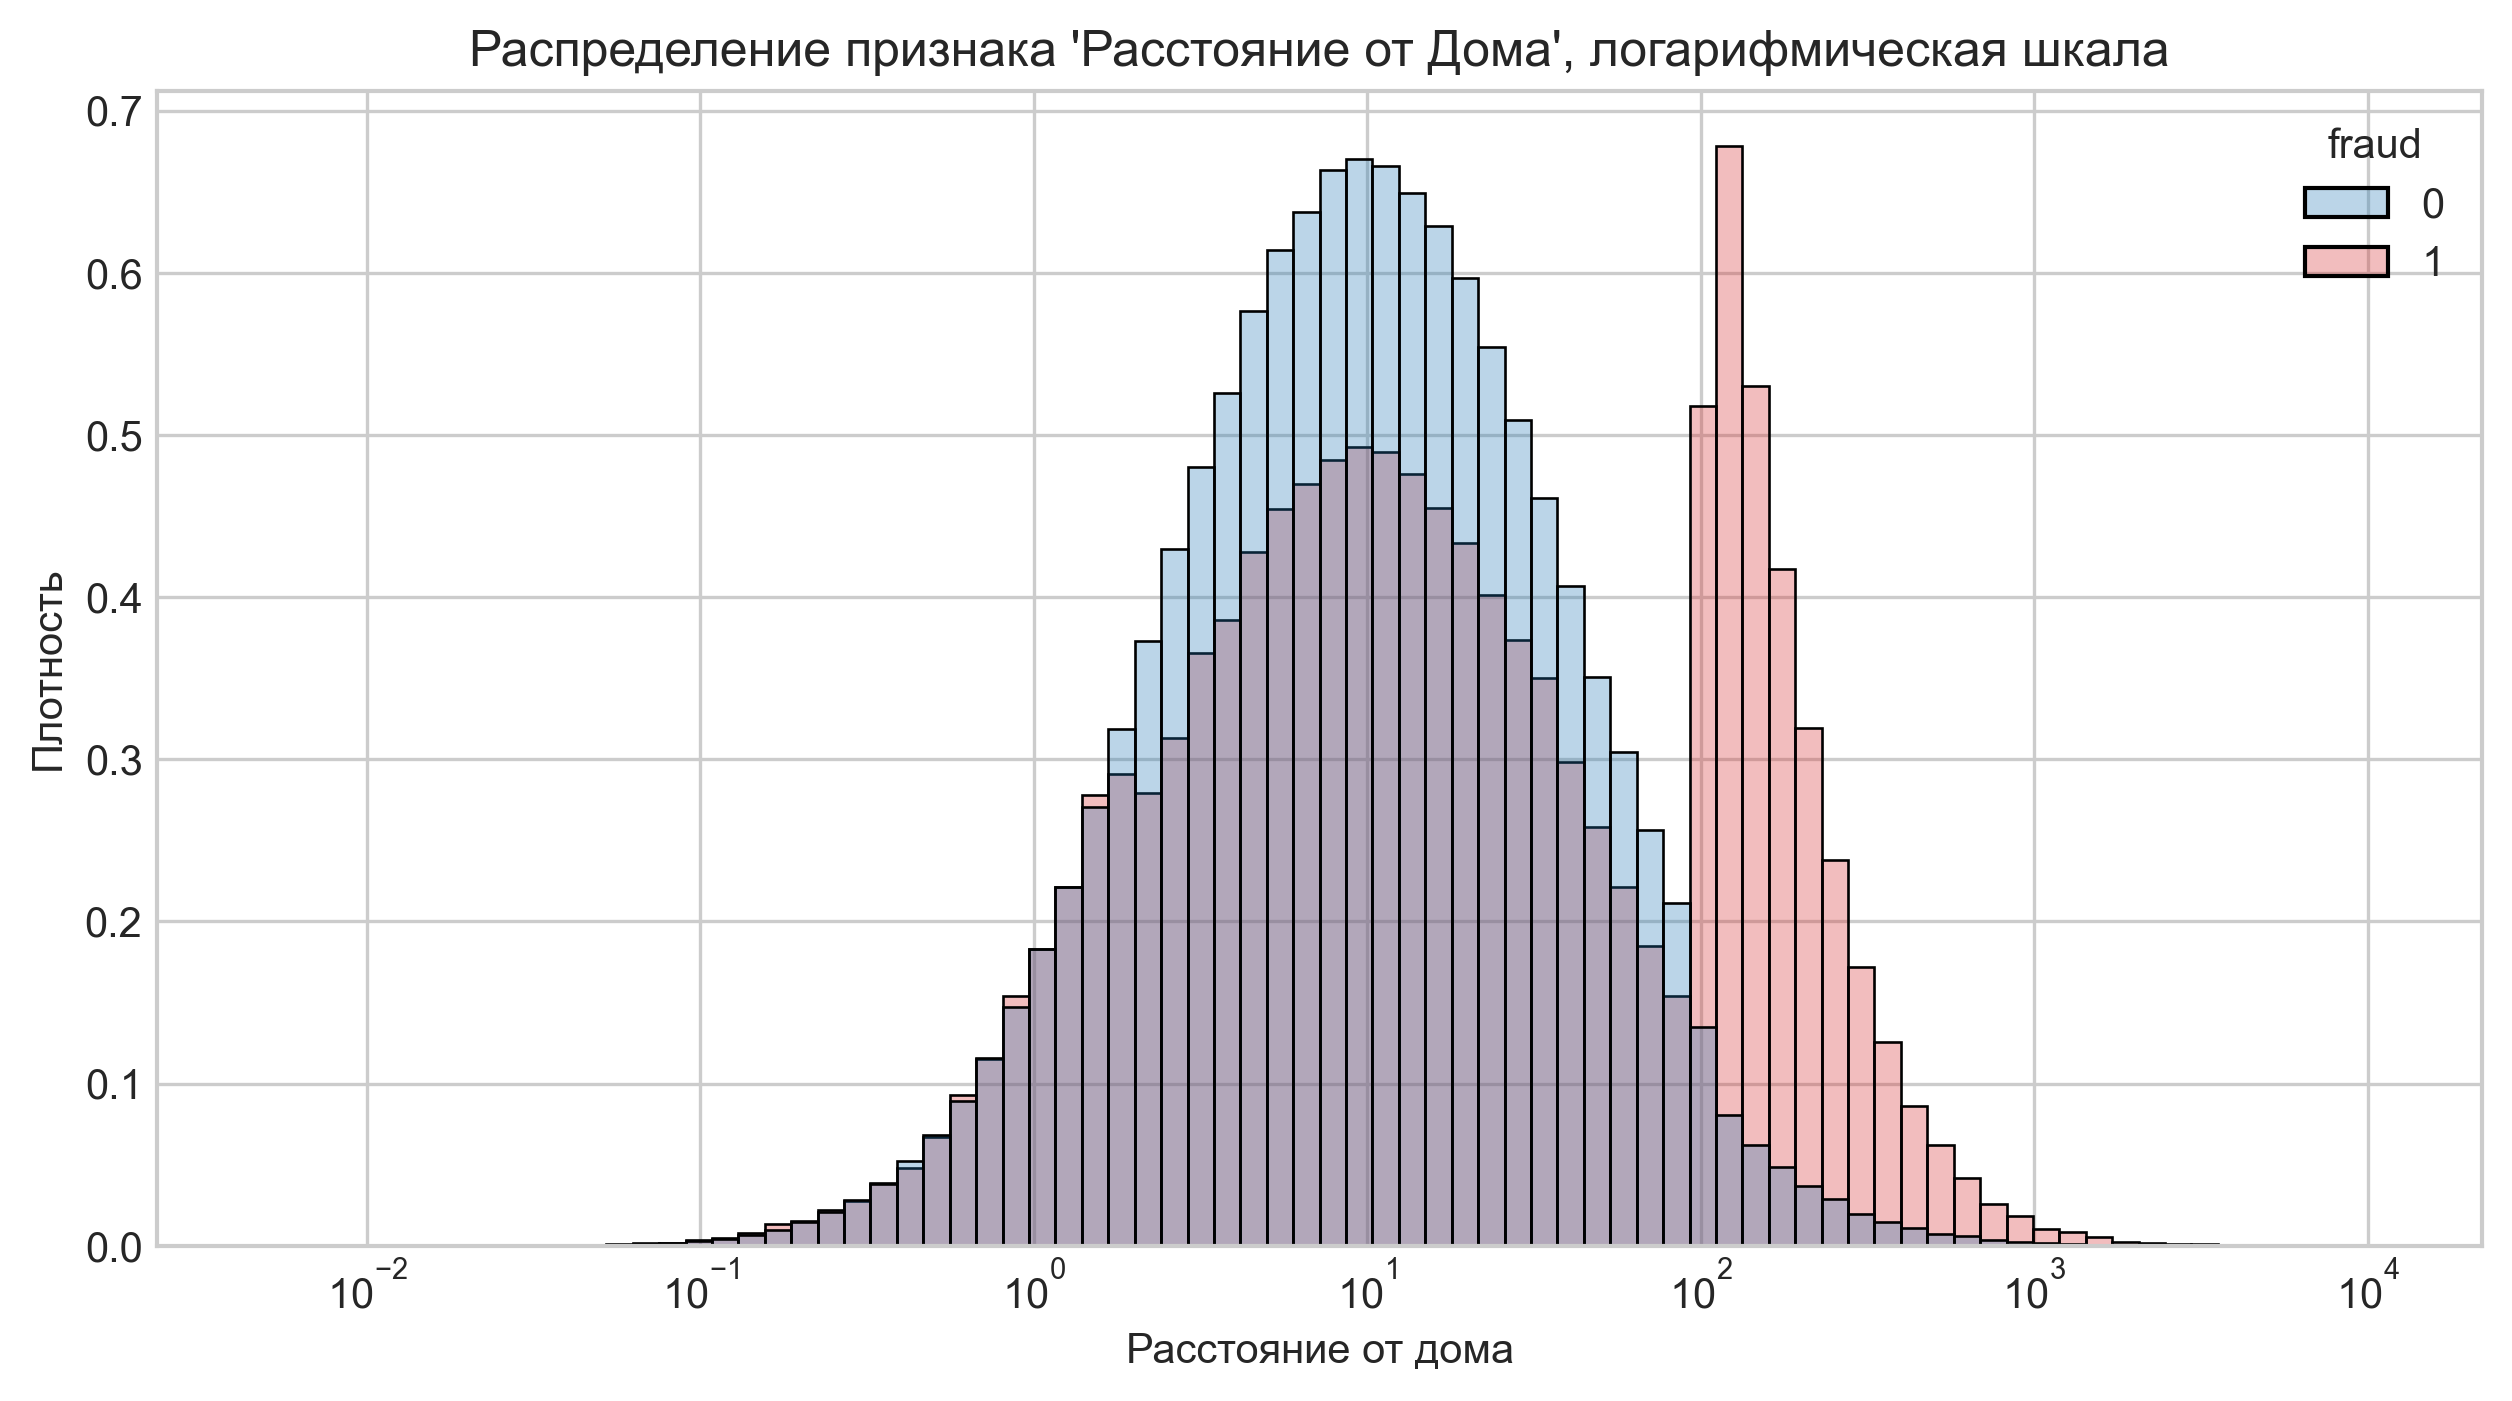

In [149]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="distance_from_home",
    hue="fraud",
    bins=80,
    hue_order=[0, 1],
    stat="density",
    common_norm=False,
    log_scale=True,
    palette={0: "tab:blue", 1: "tab:red"},
    alpha=0.3,
)

plt.title("Распределение признака 'Расстояние от Дома', логарифмическая шкала")
plt.ylabel("Плотность")
plt.xlabel("Расстояние от дома")
plt.show()

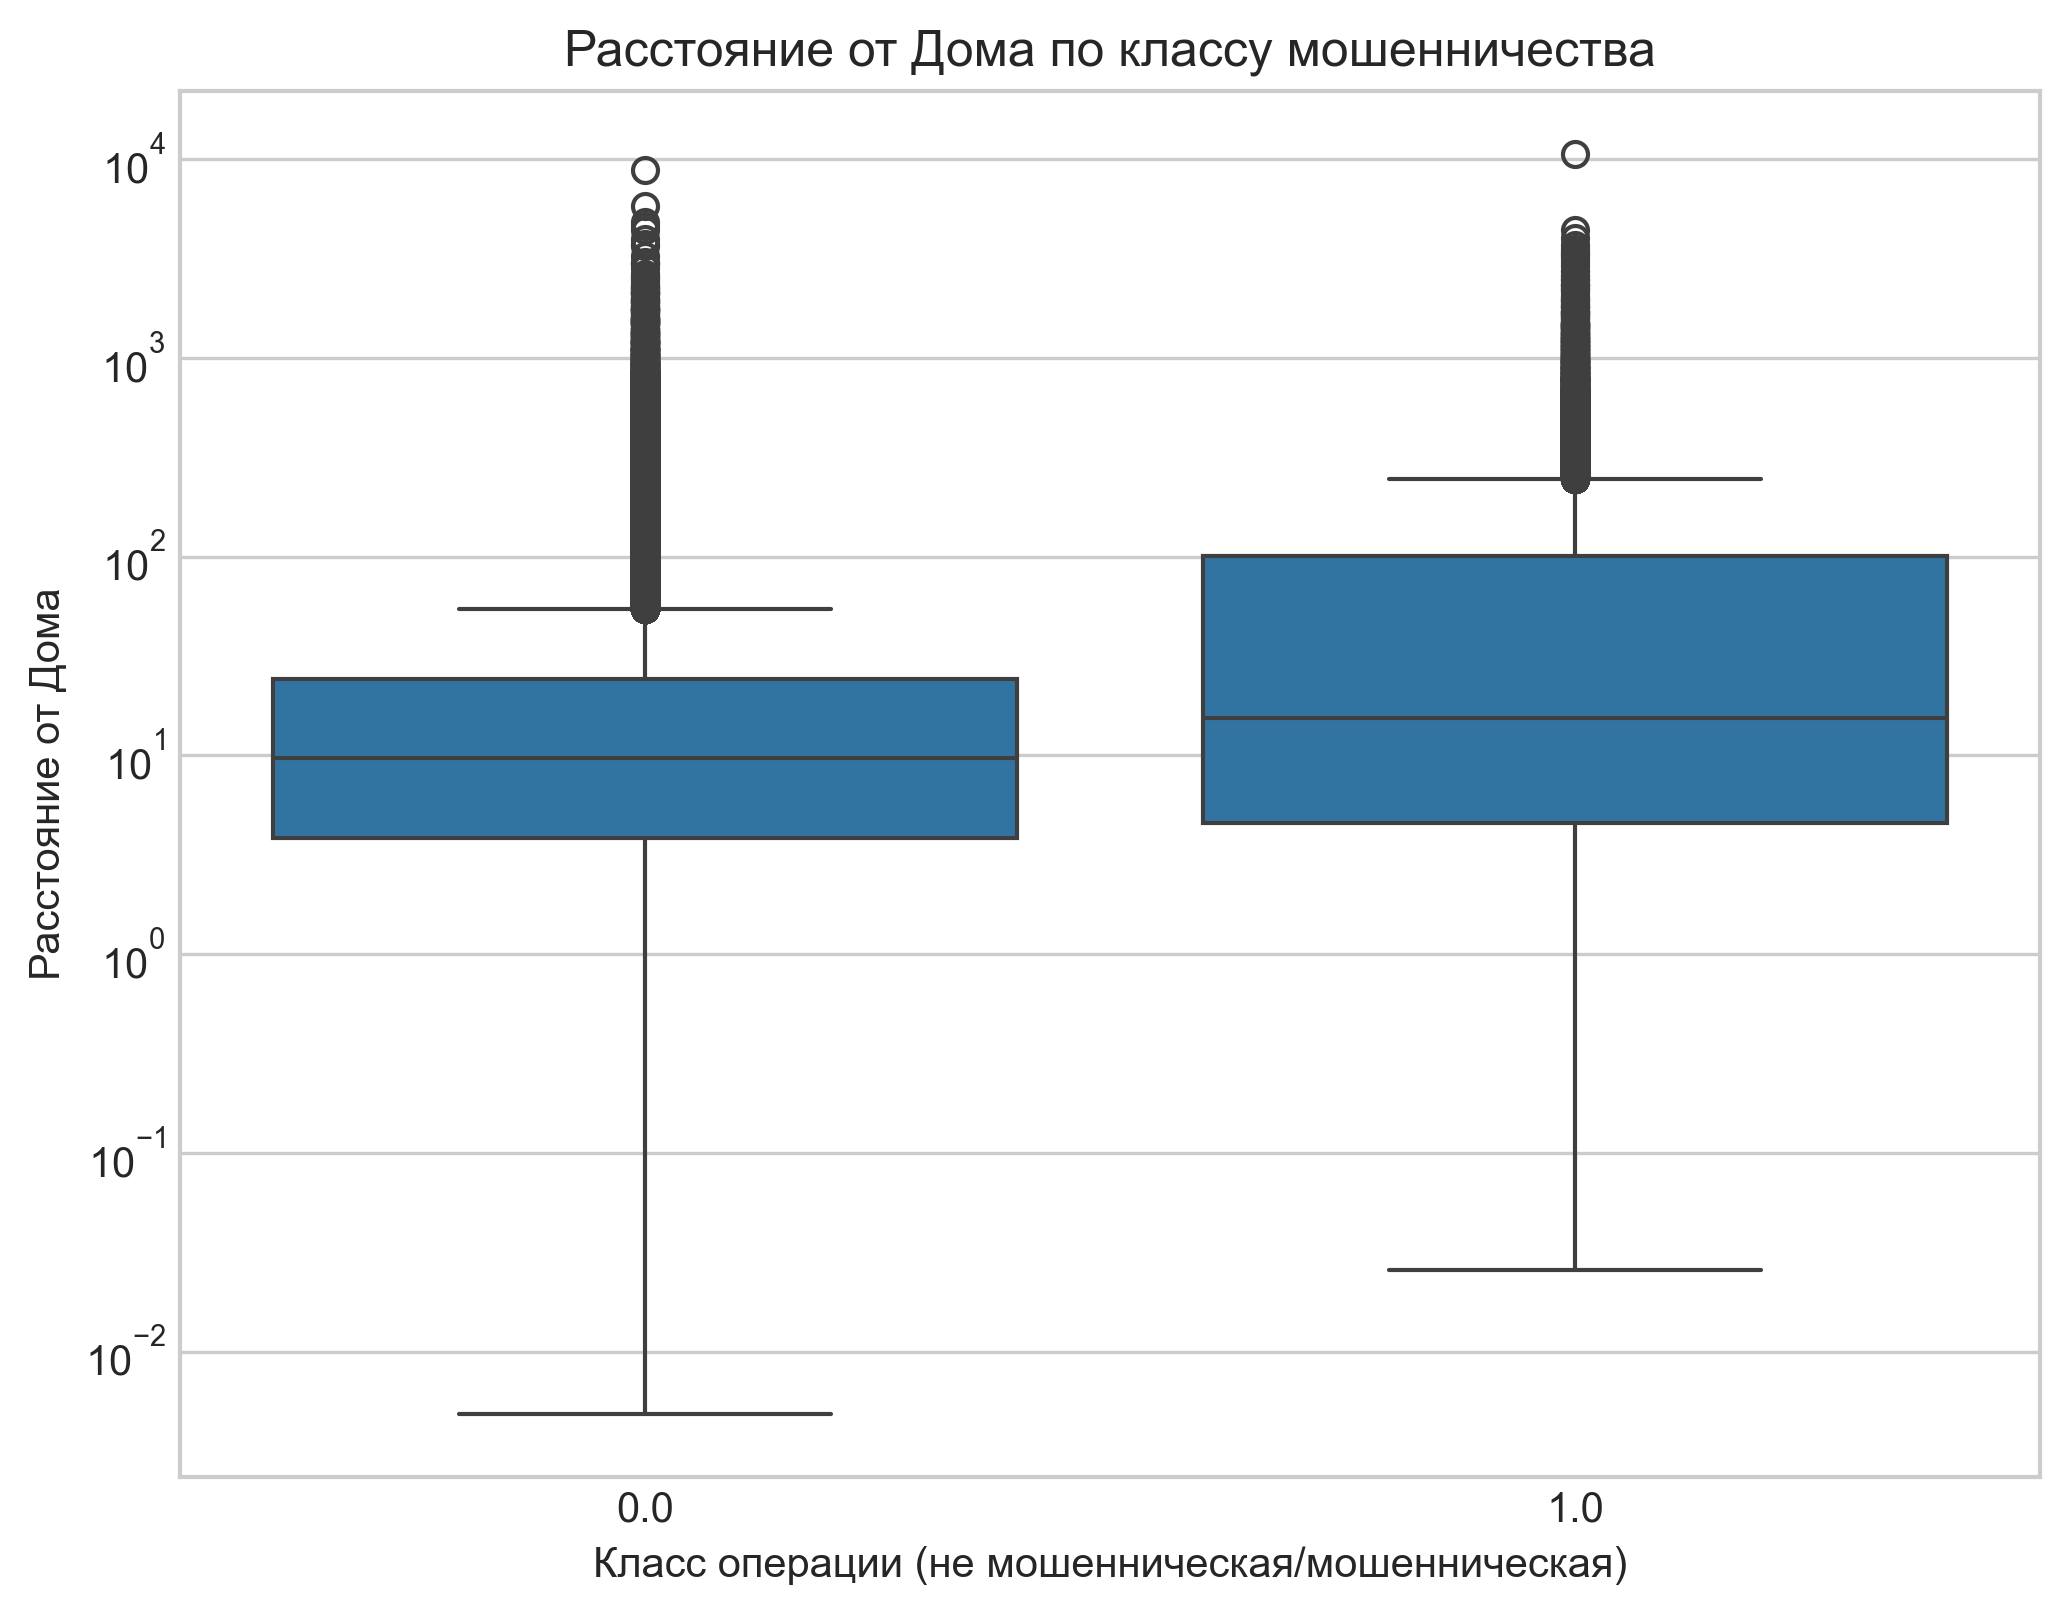

In [160]:
# Boxplot: distance_from_home
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df,
    x="fraud",
    y="distance_from_home"
)

plt.title("Расстояние от Дома по классу мошенничества")
plt.xlabel("Класс операции (не мошенническая/мошенническая)")
plt.ylabel("Расстояние от Дома")
plt.yscale("log")
plt.show()

Признак distance_from_home демонстрирует заметное различие между классами. Для мошеннических транзакций характерны большие расстояния от дома: распределение fraud смещено вправо и имеет более тяжёлый хвост по сравнению с обычными транзакциями. Это указывает на потенциально высокую информативность признака для задачи классификации мошенничества.

Boxplot признака distance_from_home показывает, что мошеннические транзакции характеризуются более высокими медианными значениями расстояния от дома по сравнению с обычными операциями. Для fraud-класса также наблюдается более широкий межквартильный диапазон и более выраженный правый хвост распределения, что указывает на большую вариативность и наличие экстремально больших значений признака.

Несмотря на присутствие выбросов в обоих классах, распределение fraud смещено в сторону больших расстояний, что свидетельствует о потенциальной информативности признака для задачи обнаружения мошеннических транзакций.Анализ распределения признака distance_from_home показывает, что мошеннические транзакции в среднем совершаются на больших расстояниях от дома по сравнению с обычными операциями. Несмотря на наличие выбросов в обоих классах, для fraud характерны более высокие медианные значения и более тяжёлый правый хвост распределения. Это свидетельствует о потенциальной значимости признака для классификации мошеннических операций.

### Распределение Расстояние от последней транзакции

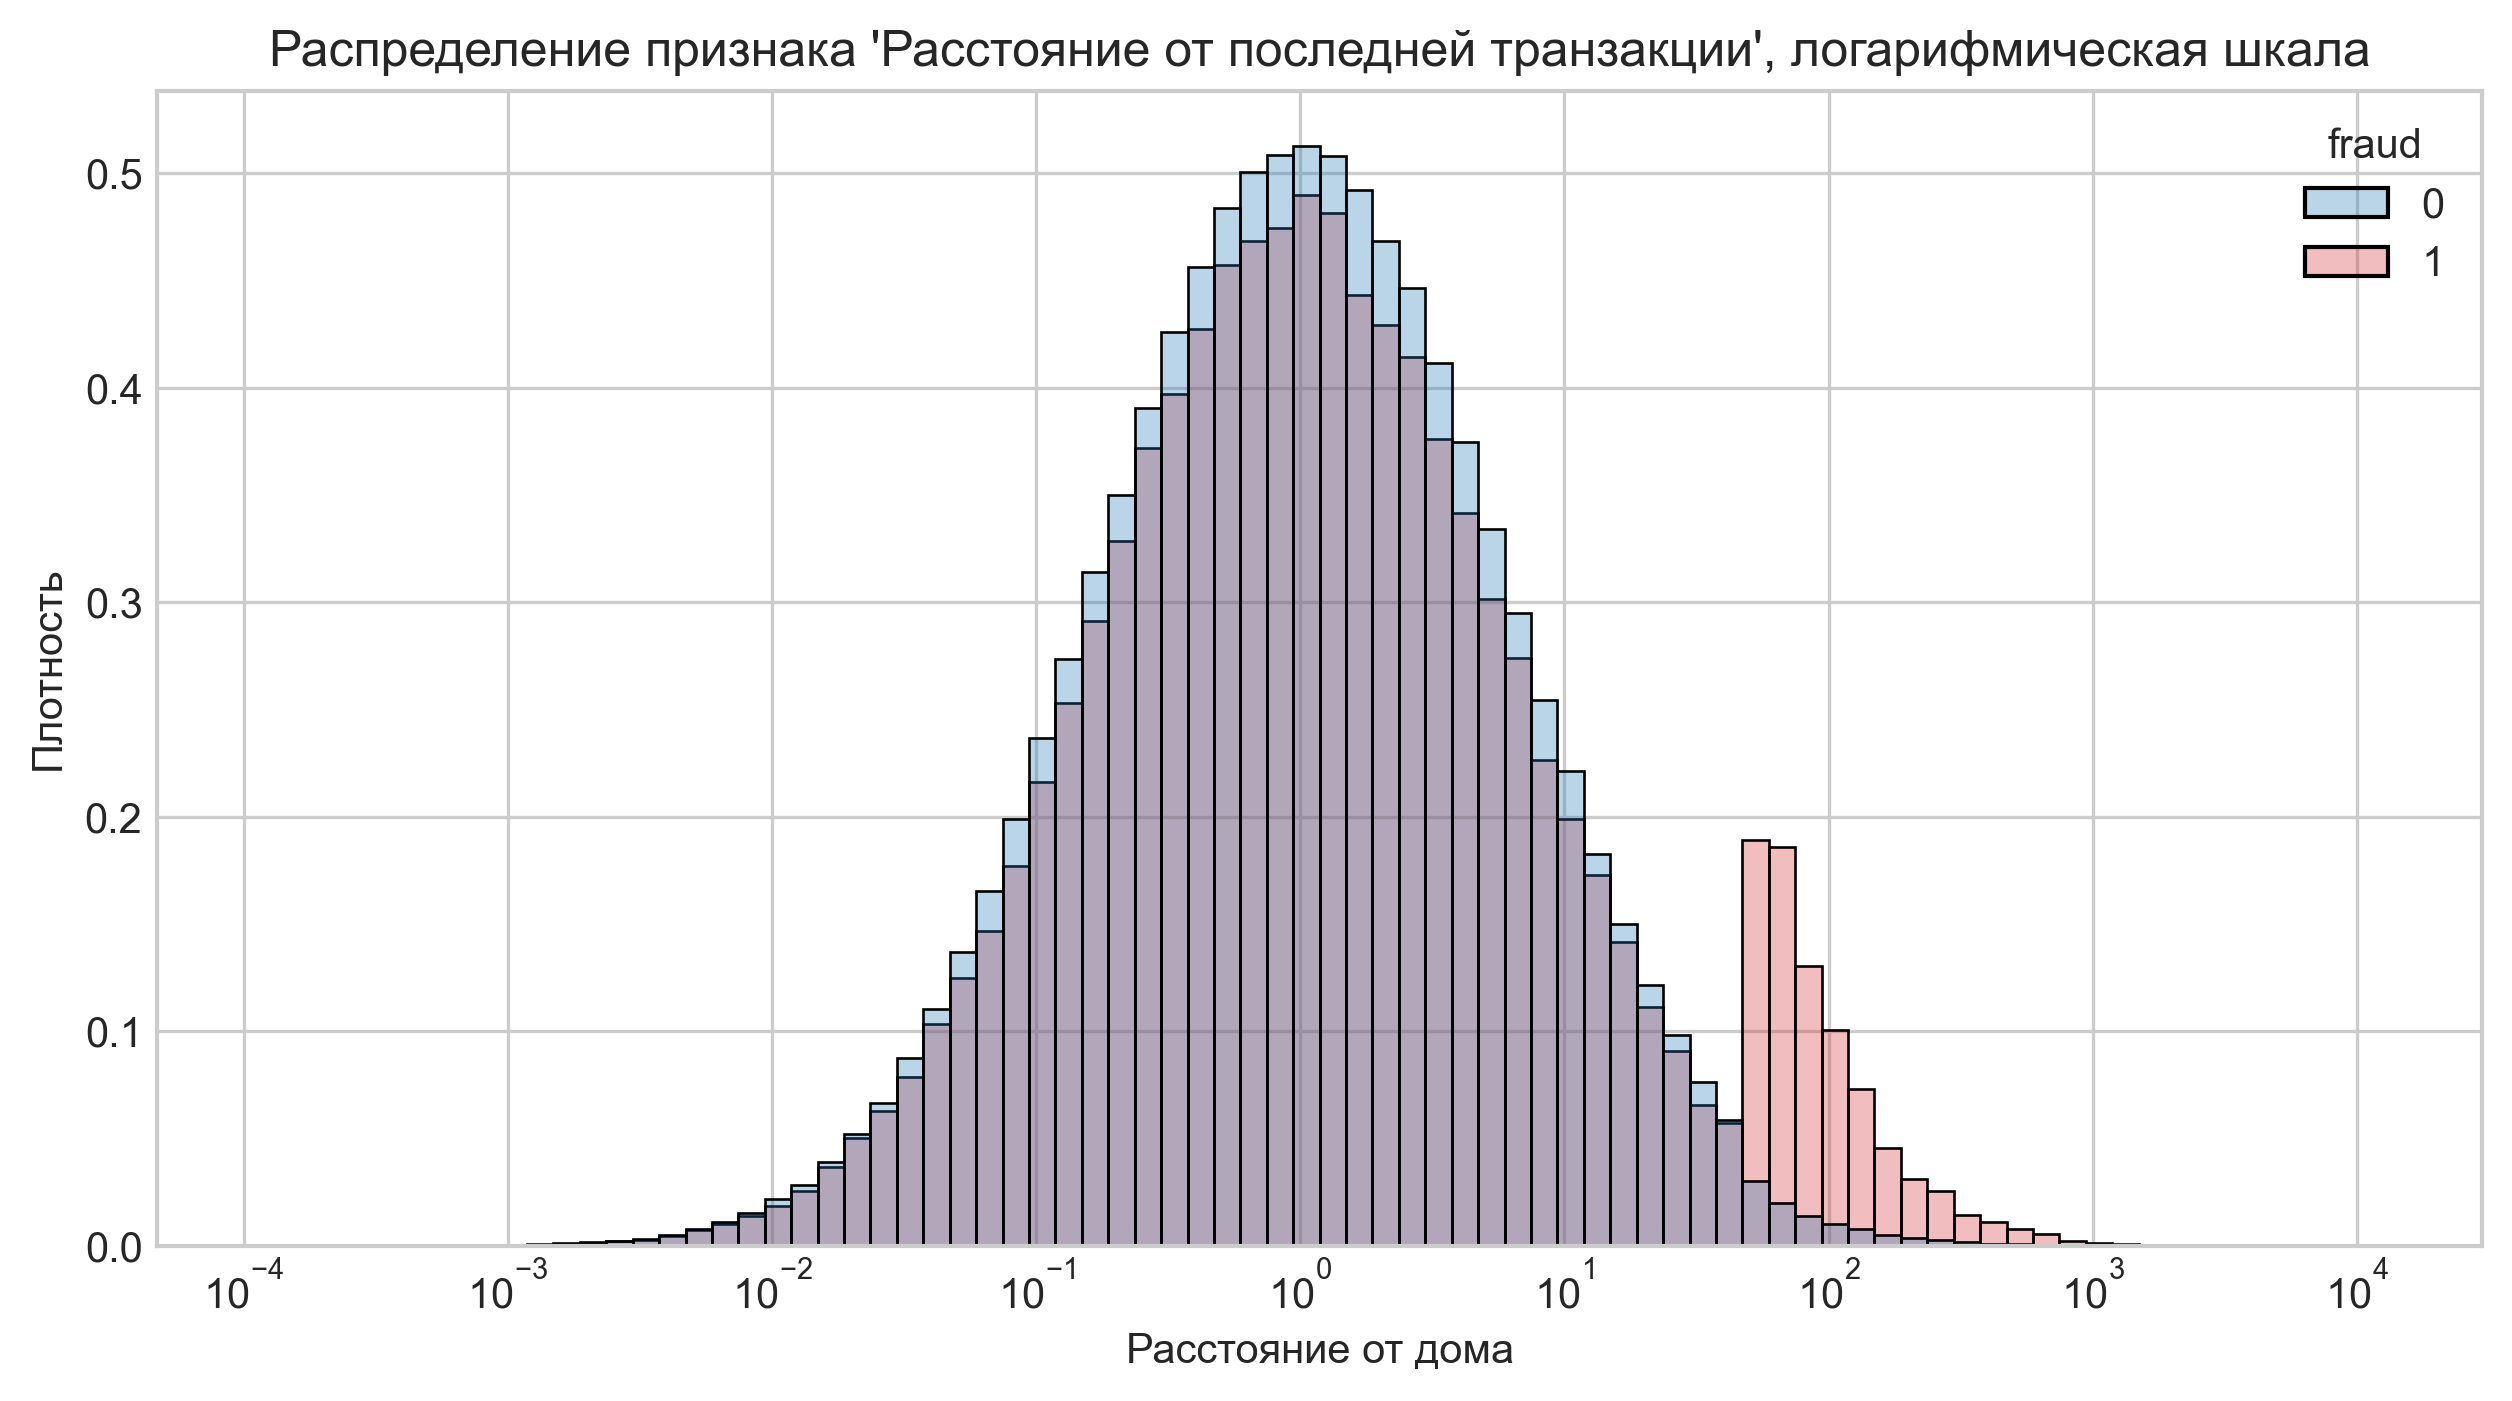

In [146]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="distance_from_last_transaction",
    hue="fraud",
    bins=80,
    hue_order=[0, 1],
    stat="density",
    common_norm=False,
    log_scale=True,
    palette={0: "tab:blue", 1: "tab:red"},
    alpha=0.3,
)

plt.title("Распределение признака 'Расстояние от последней транзакции', логарифмическая шкала")
plt.ylabel("Плотность")
plt.xlabel("Расстояние от последней транзакции")
plt.show()

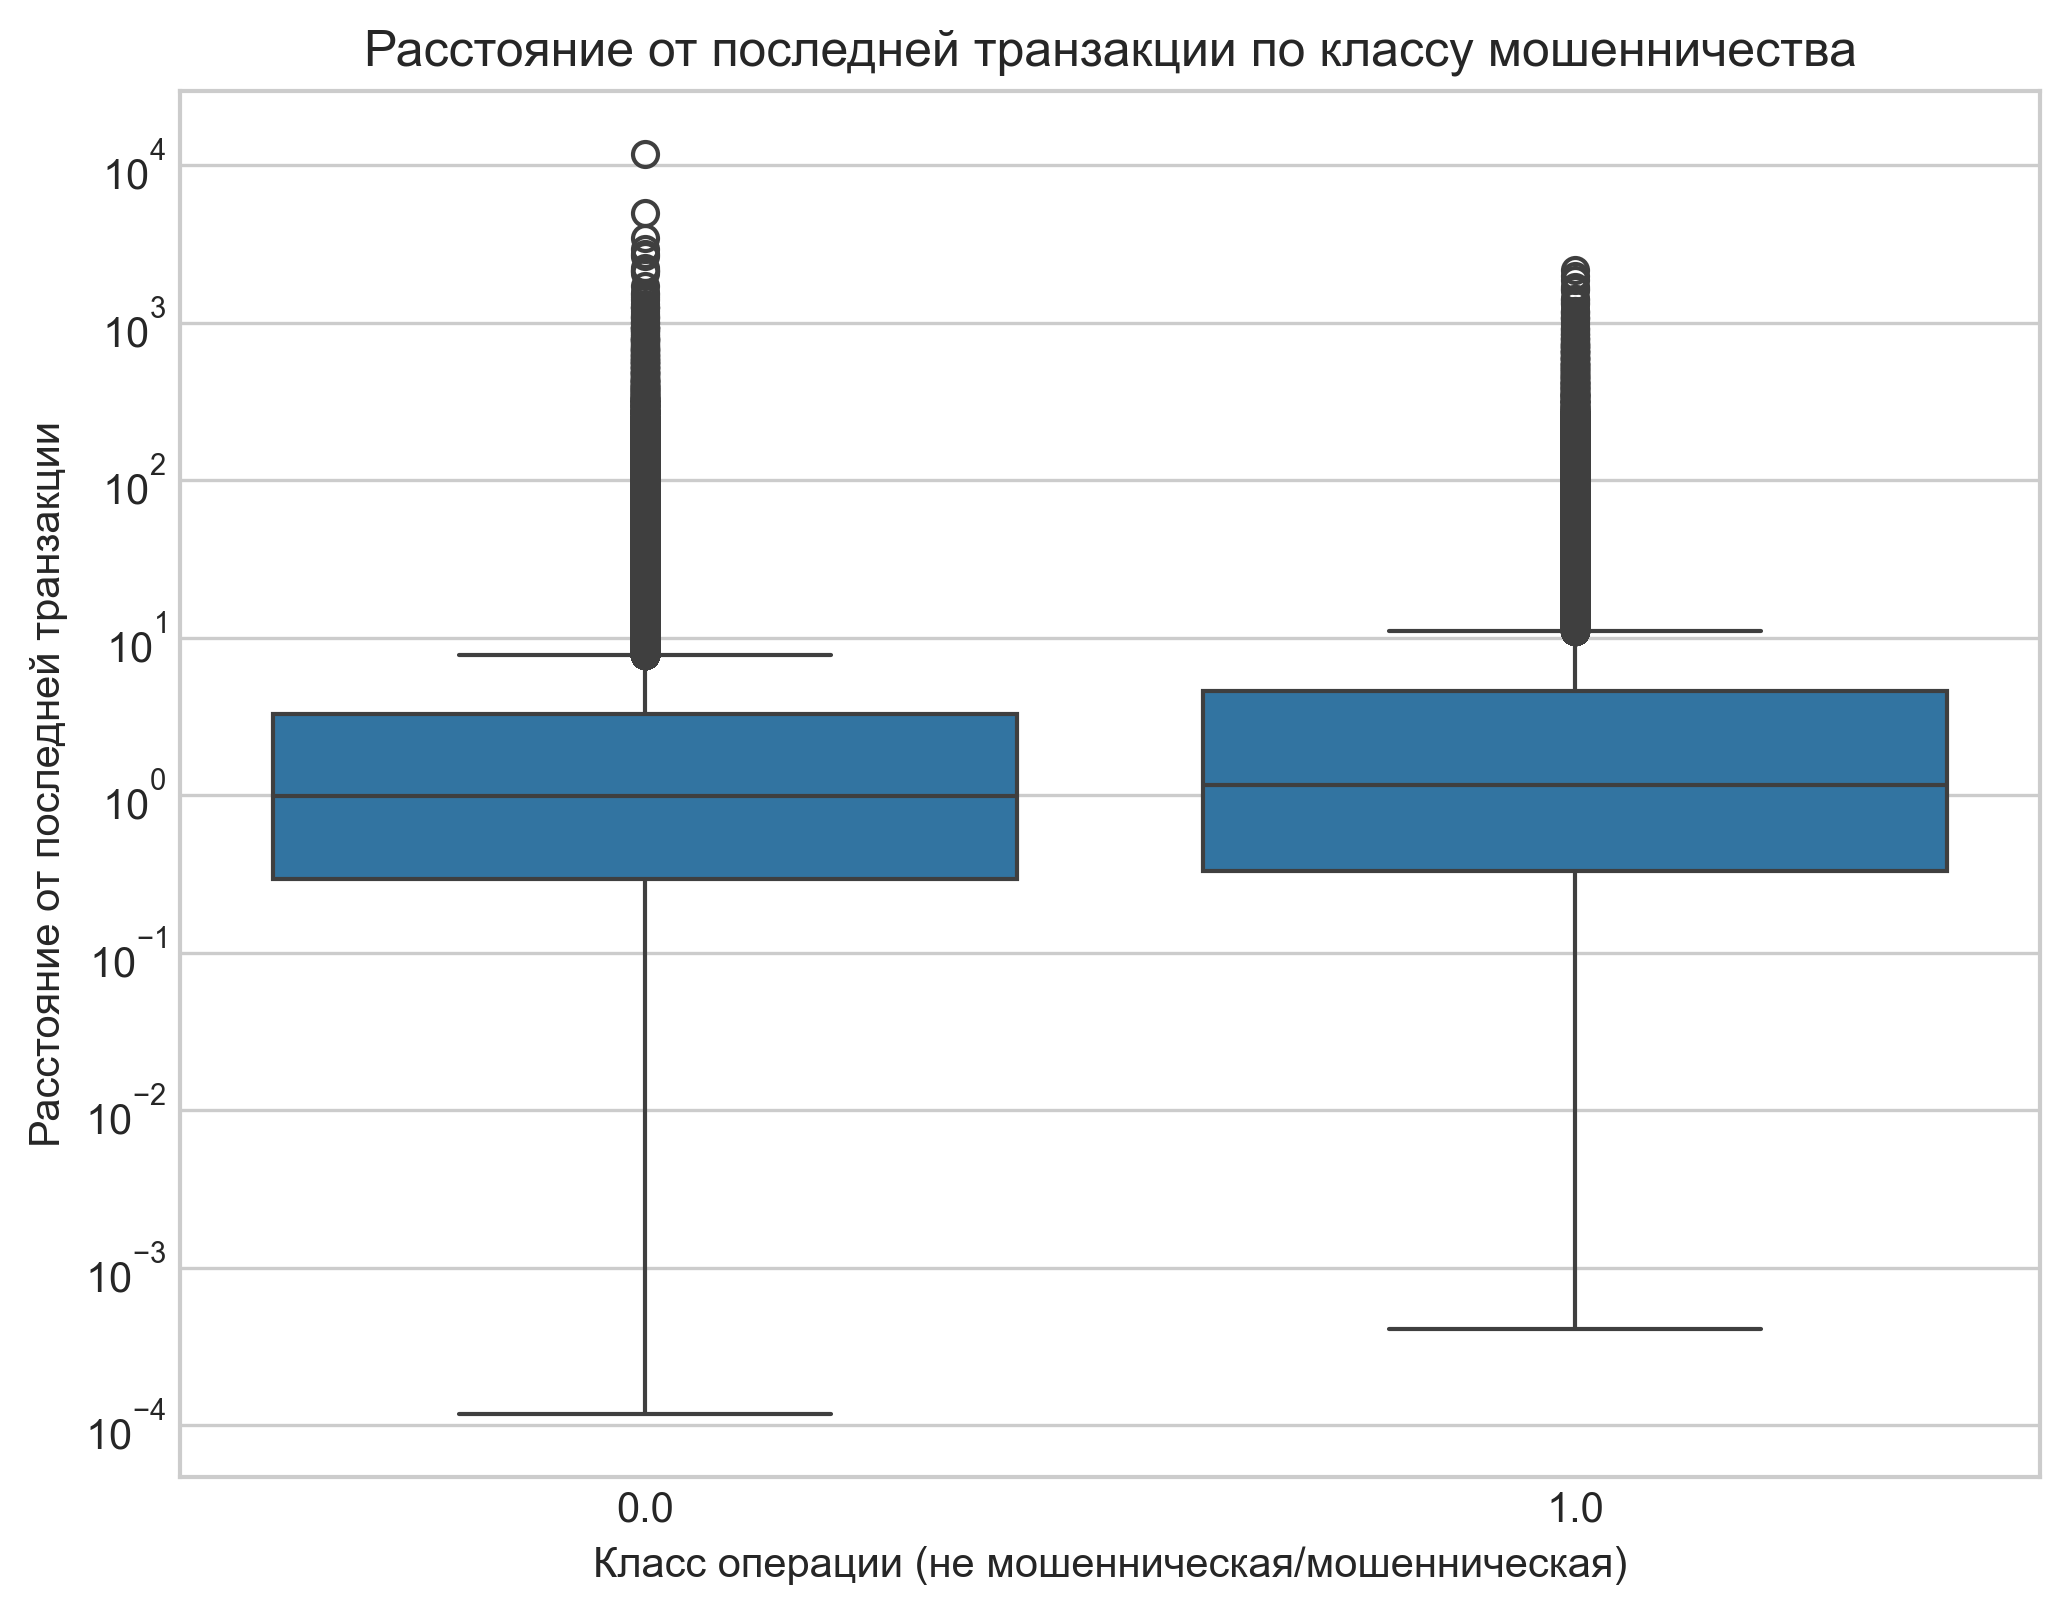

In [161]:
sns.boxplot(
    data=df,
    x="fraud",
    y="distance_from_last_transaction"
)

plt.title("Расстояние от последней транзакции по классу мошенничества")
plt.xlabel("Класс операции (не мошенническая/мошенническая)")
plt.ylabel("Расстояние от последней транзакции")
plt.yscale("log")
plt.show()

Большая часть распределений normal и fraud совпадает, поэтому признак слабо разделяет классы. Однако у fraud наблюдается небольшой сдвиг к большим значениям и более тяжёлый правый хвост, что может делать большие значения признака индикатором мошенничества.

Boxplot признака distance_from_last_transaction показывает, что распределения обычных и мошеннических транзакций существенно перекрываются. Медианные значения признака для fraud и normal отличаются незначительно, что указывает на ограниченную разделяющую способность признака.

При этом для мошеннических операций наблюдается несколько больший разброс значений и более выраженный правый хвост распределения, что может свидетельствовать о тенденции к увеличению расстояния от предыдущей транзакции для fraud-операций.

Таким образом, признак может быть полезен в комбинации с другими признаками, однако его информативность отдельно ограничена.

### Распределение Отношение к медианной сумме транзакции

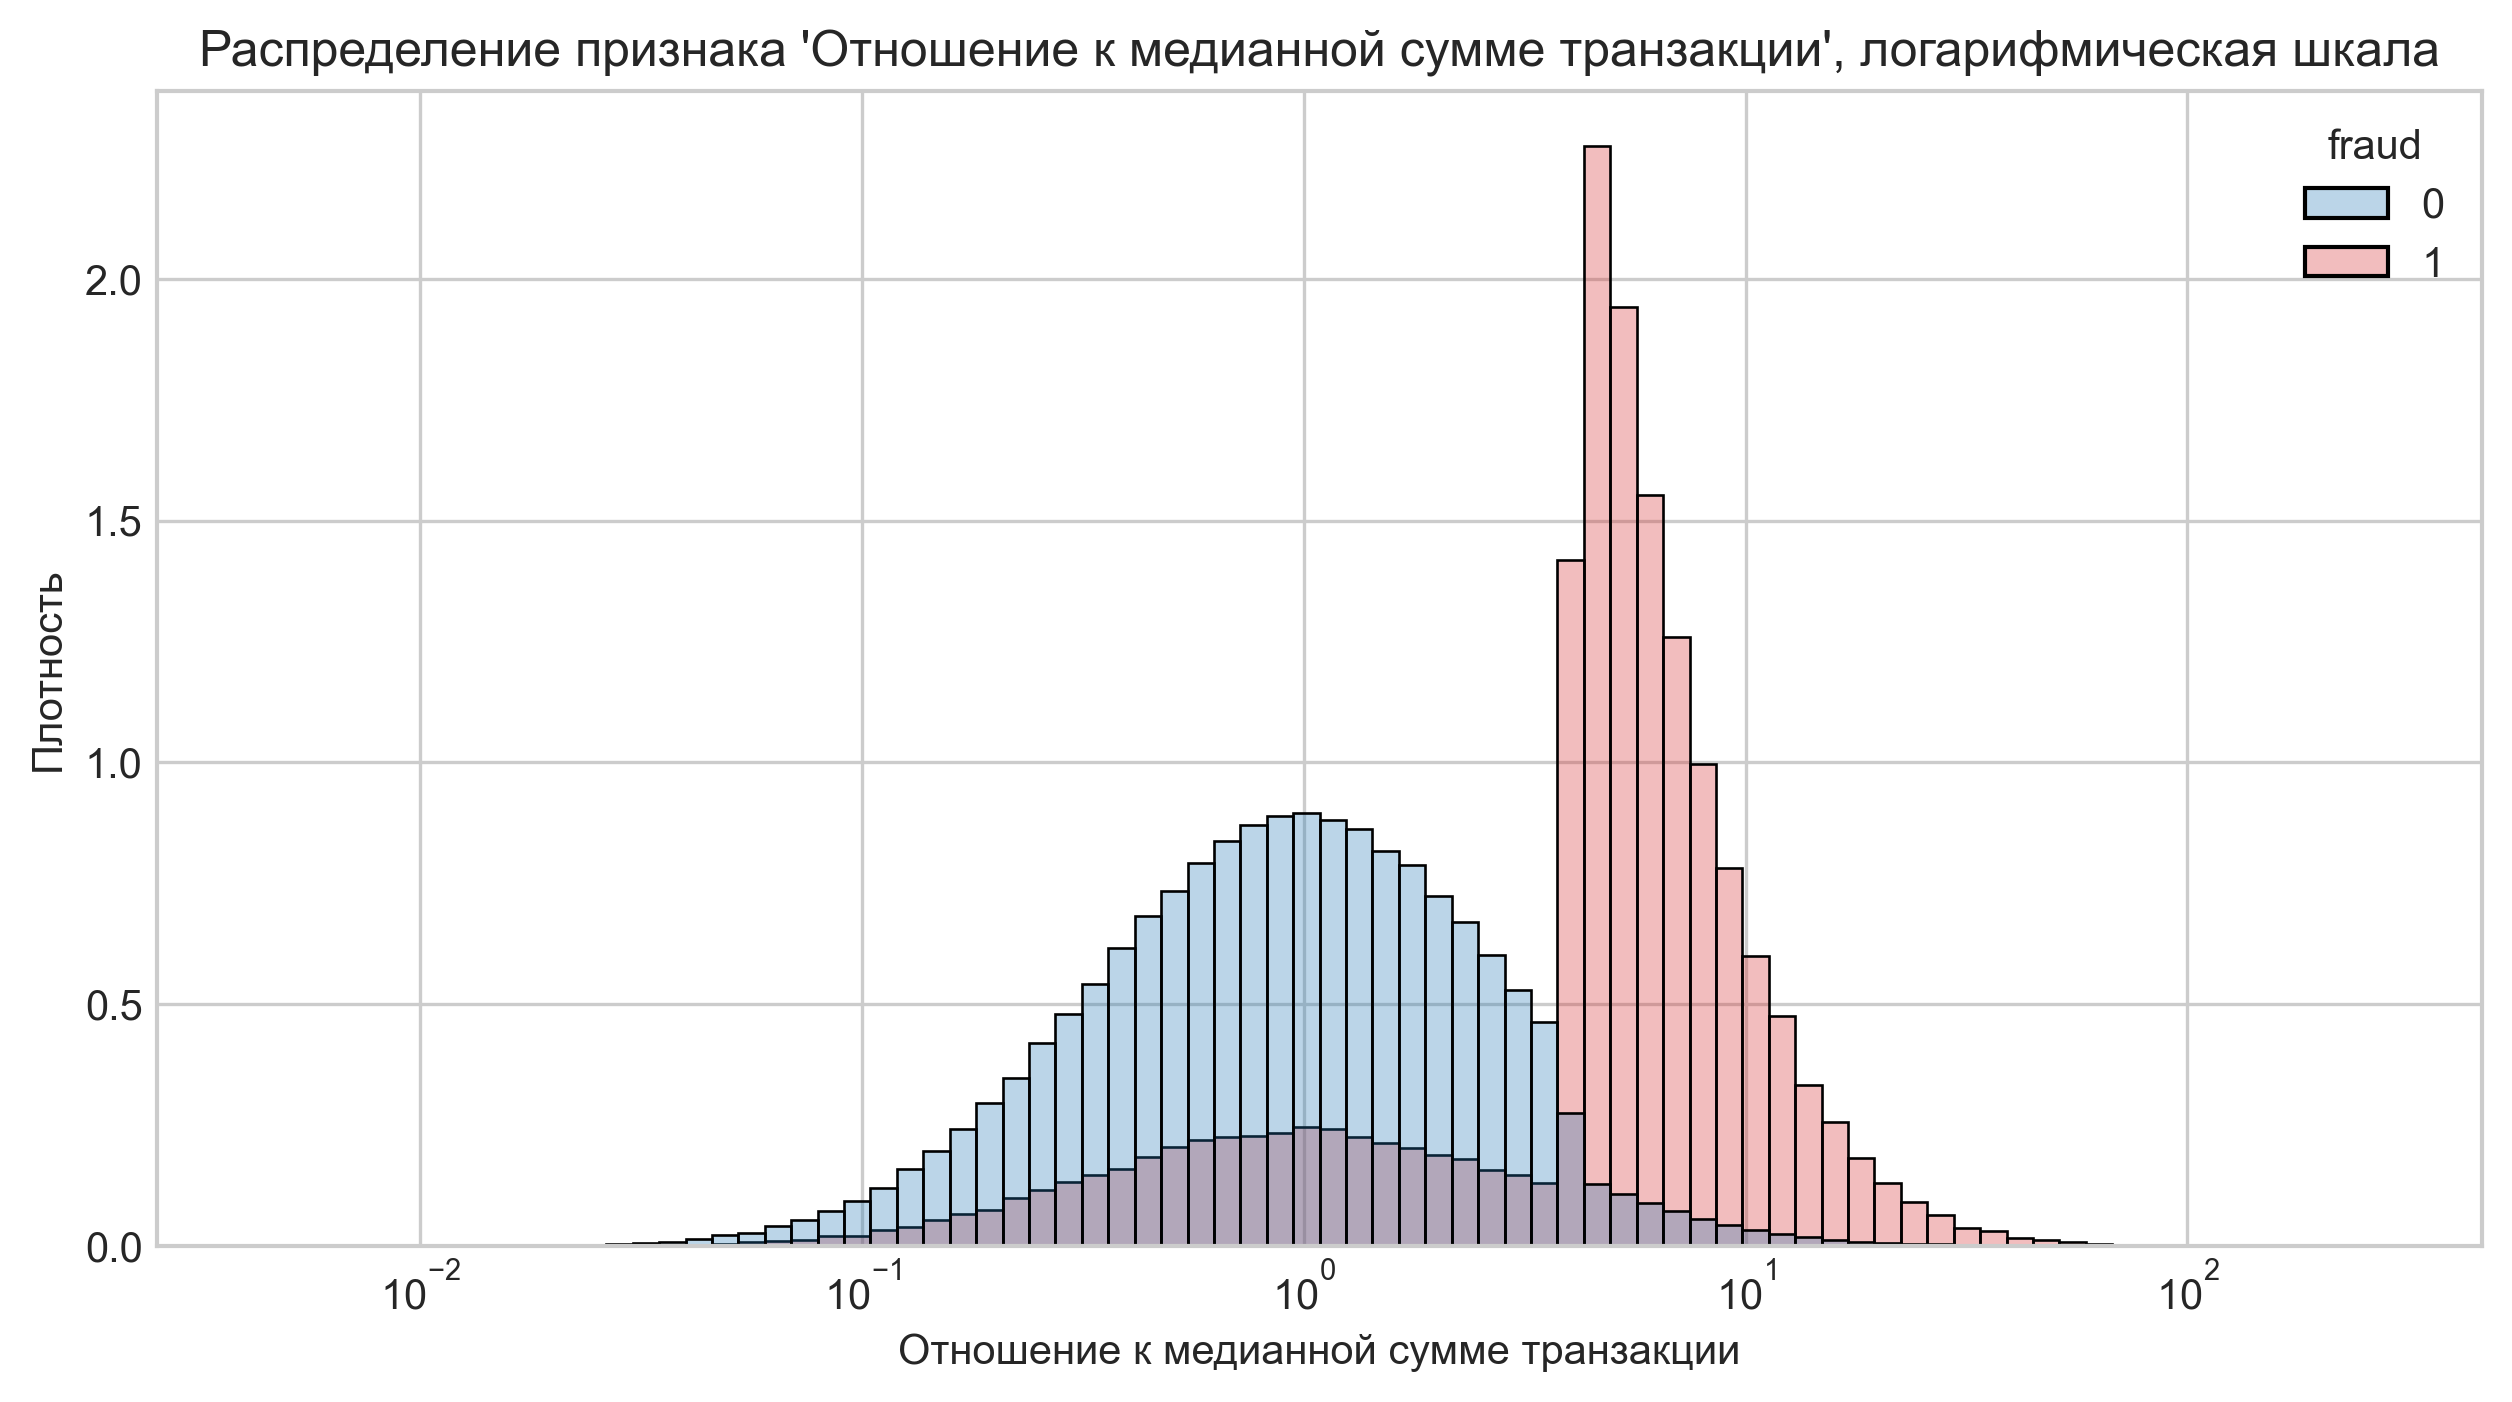

In [151]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="ratio_to_median_purchase_price",
    hue="fraud",
    bins=80,
    hue_order=[0, 1],
    stat="density",
    common_norm=False,
    log_scale=True,
    palette={0: "tab:blue", 1: "tab:red"},
    alpha=0.3,
)

plt.title("Распределение признака 'Отношение к медианной сумме транзакции', логарифмическая шкала")
plt.ylabel("Плотность")
plt.xlabel("Отношение к медианной сумме транзакции")
plt.show()

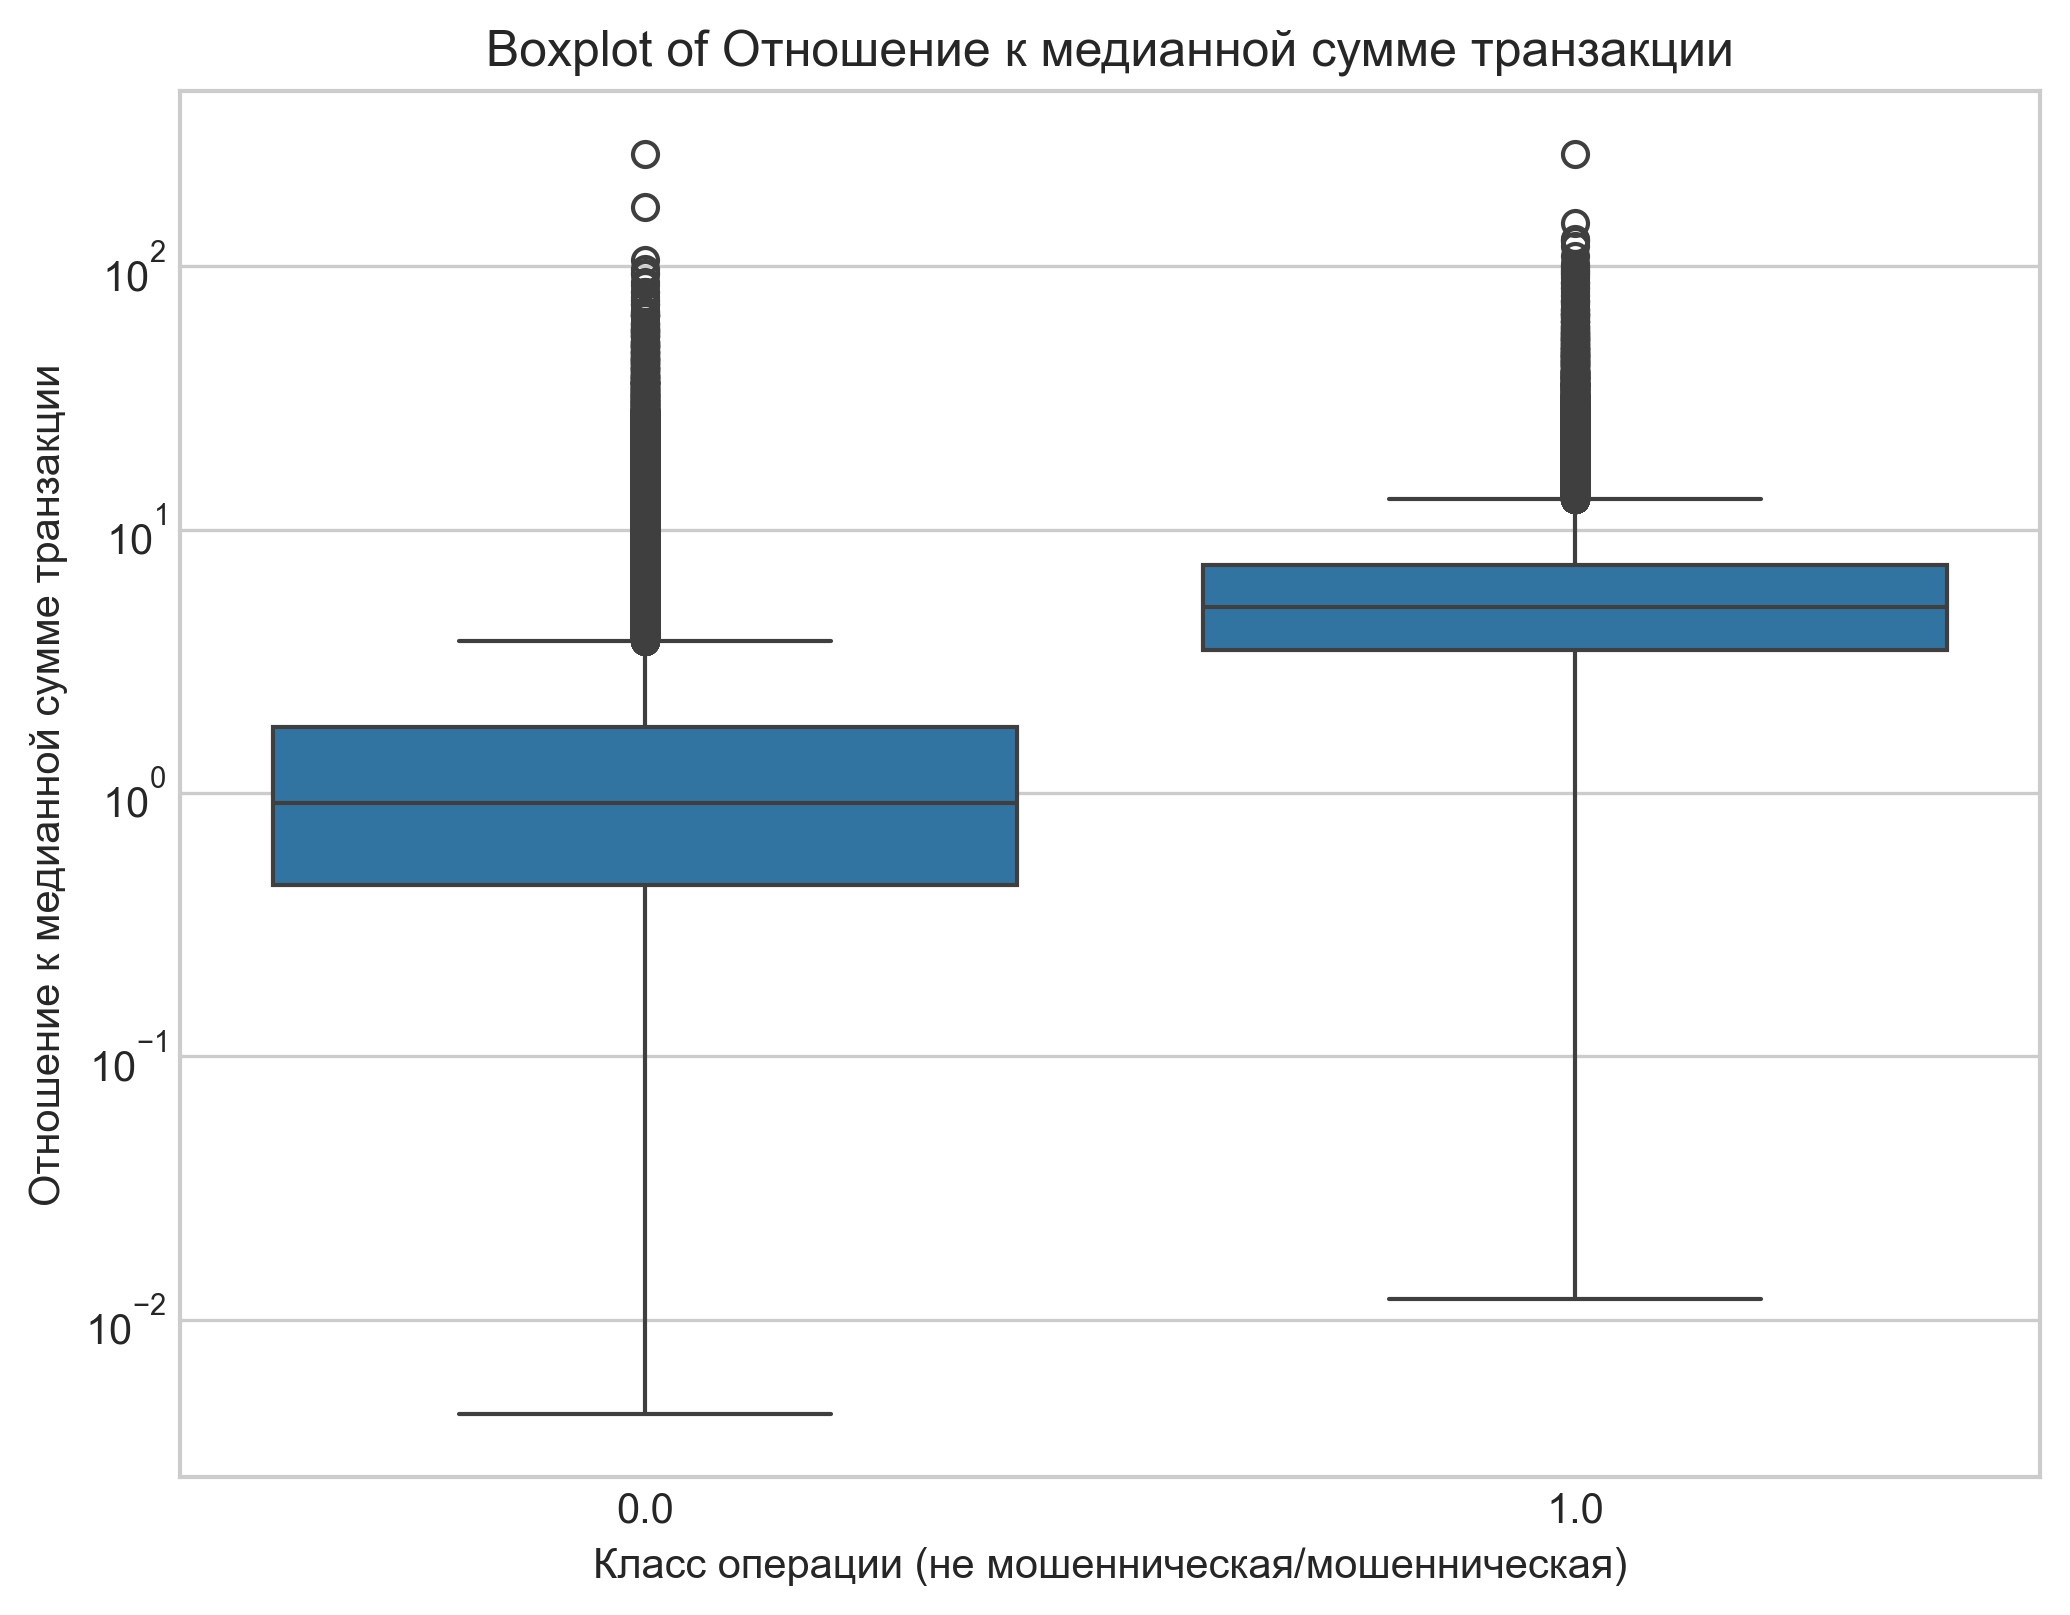

In [159]:
sns.boxplot(
    data=df,
    x="fraud",
    y="ratio_to_median_purchase_price"
)

plt.title("Отношение к медианной сумме транзакции")
plt.xlabel("Класс операции (не мошенническая/мошенническая)")
plt.ylabel("Отношение к медианной сумме транзакции")
plt.yscale("log")
plt.show()

Признак ratio_to_median_purchase_price демонстрирует выраженное различие между классами. Для обычных транзакций характерны значения, близкие к 1, что соответствует типичному размеру покупок пользователя. Мошеннические транзакции существенно смещены вправо, что указывает на склонность fraud-операций значительно превышать привычные суммы транзакций пользователя. Признак обладает высокой разделяющей способностью и потенциально является одним из наиболее информативных для задачи обнаружения мошенничества.

Boxplot признака ratio_to_median_purchase_price демонстрирует выраженные различия между классами. Для мошеннических транзакций характерны существенно более высокие медианные значения признака по сравнению с обычными операциями. Распределение fraud смещено в сторону больших значений, что указывает на склонность мошеннических транзакций значительно превышать типичные суммы покупок пользователя.

Несмотря на наличие выбросов в обоих классах, признак демонстрирует хорошую разделяющую способность и может рассматриваться как один из наиболее информативных признаков для задачи обнаружения мошенничества.

### Анализ бинарных признаков

Анализ бинарного признака online_order показал существенную связь с целевой переменной fraud. Среди операций, не являющихся онлайн-заказами, доля мошеннических транзакций составляет около 1.34%, тогда как для онлайн-операций данный показатель достигает 12.7%.
Таким образом, вероятность мошенничества для онлайн-заказов значительно выше, что позволяет рассматривать признак online_order как информативный для задачи обнаружения мошеннических операций.

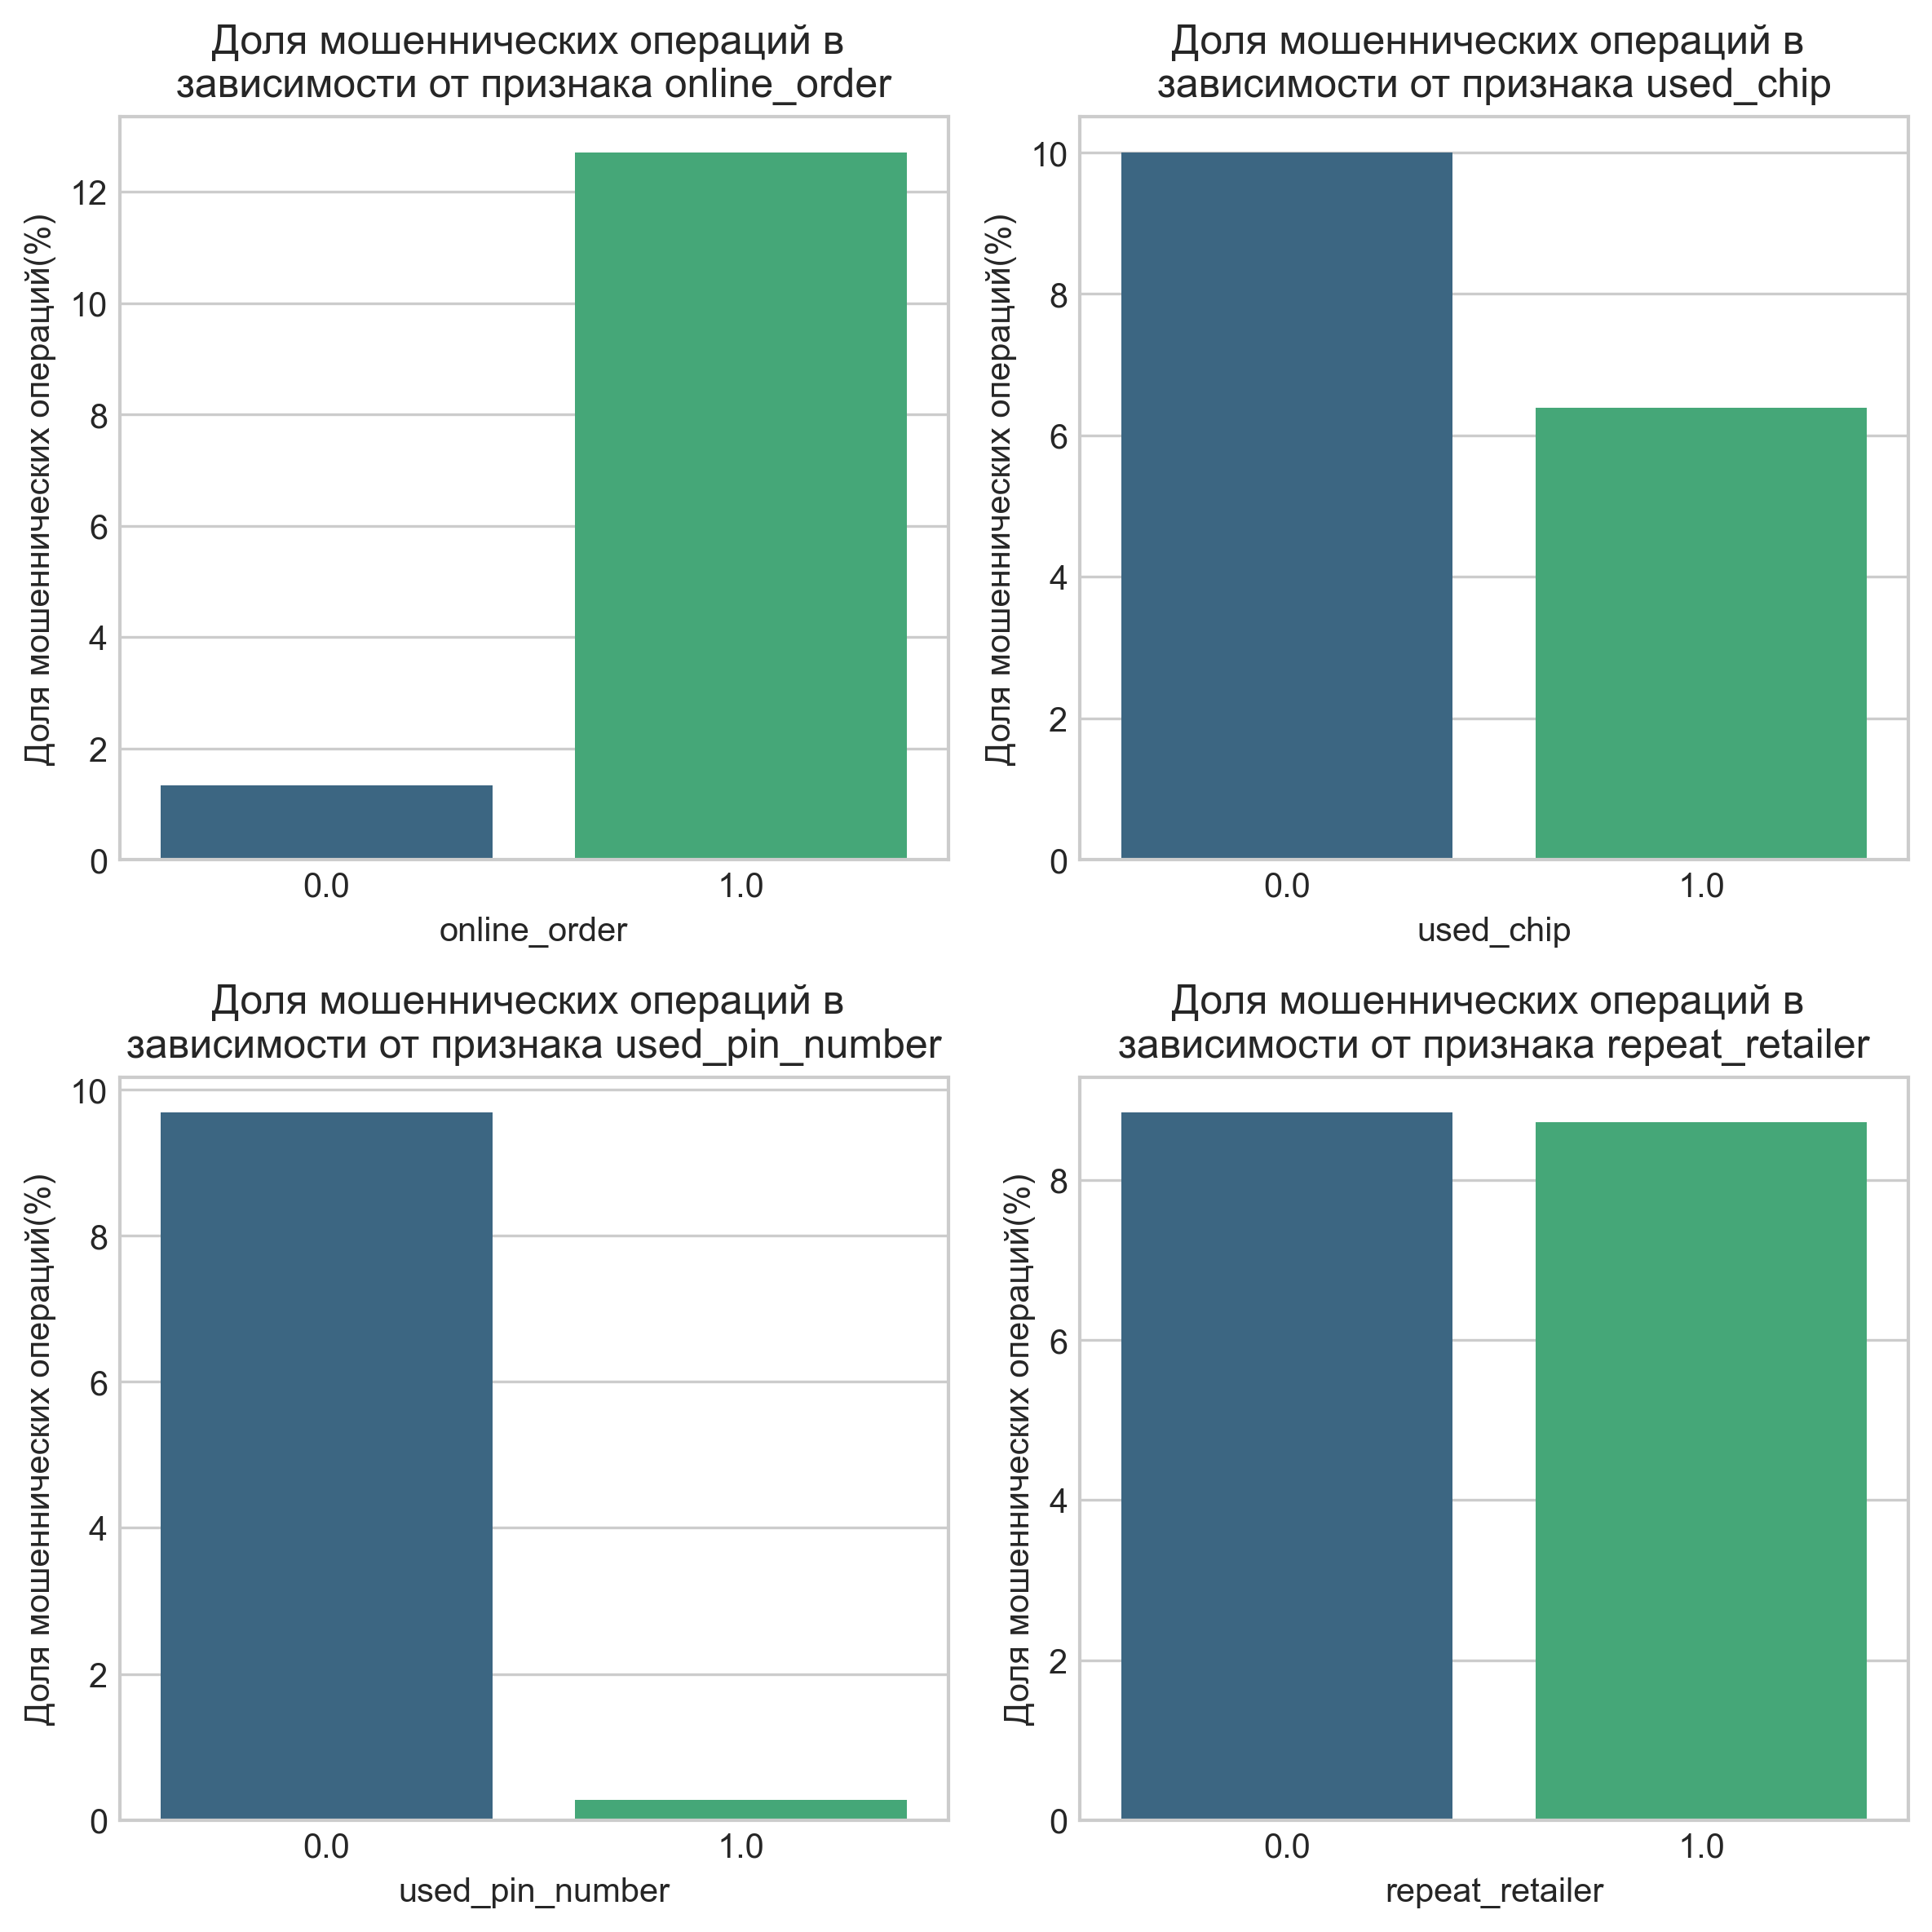

In [199]:
binary_features = [
    "online_order",
    "used_chip",
    "used_pin_number",
    "repeat_retailer"
]

fig, axes = plt.subplots(2, 2, figsize=(8, 8))

axes = axes.flatten()

for i, feature in enumerate(binary_features):
    fraud_rate = df.groupby(feature)["fraud"].mean() * 100

    sns.barplot(
        x=fraud_rate.index,
        y=fraud_rate.values,
        hue=fraud_rate.index,
        ax=axes[i],
        palette="viridis",
        legend=False
    )

    axes[i].set_title(f"Доля мошеннических операций в \nзависимости от признака {feature}")
    axes[i].set_ylabel("Доля мошеннических операций(%)")
    axes[i].set_xlabel(feature)

plt.tight_layout()
plt.show()

Анализ бинарных признаков показал, что наиболее информативными являются online_order и used_pin_number. Для онлайн-транзакций доля мошеннических операций значительно выше, тогда как использование PIN-кода связано с резким снижением вероятности fraud. Признак used_chip также демонстрирует умеренную связь с целевой переменной, в то время как repeat_retailer практически не влияет на вероятность мошенничества.

## Анализ признаков вывод

В результате анализа признаков было установлено, что наибольшей информативностью обладают признаки
ratio_to_median_purchase_price, distance_from_home и online_order.
Признак ratio_to_median_purchase_price продемонстрировал наиболее выраженное различие между классами, что указывает на важность аномального размера транзакции относительно типичного поведения пользователя.
Признак distance_from_home также показал значимые различия между мошенническими и обычными операциями: для fraud характерны большие расстояния и более тяжёлый правый хвост распределения.
Бинарный признак online_order продемонстрировал существенное увеличение доли мошеннических операций среди онлайн-заказов.
При этом признак distance_from_last_transaction обладает более слабой разделяющей способностью, однако может быть полезен в комбинации с другими признаками в рамках модели машинного обучения.

## Анализ разделимости признаков

### Метод главных компонент

In [200]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

features = df.drop(columns=["fraud"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PCA1": X_pca[:, 0],
    "PCA2": X_pca[:, 1],
    "fraud": df["fraud"]
})

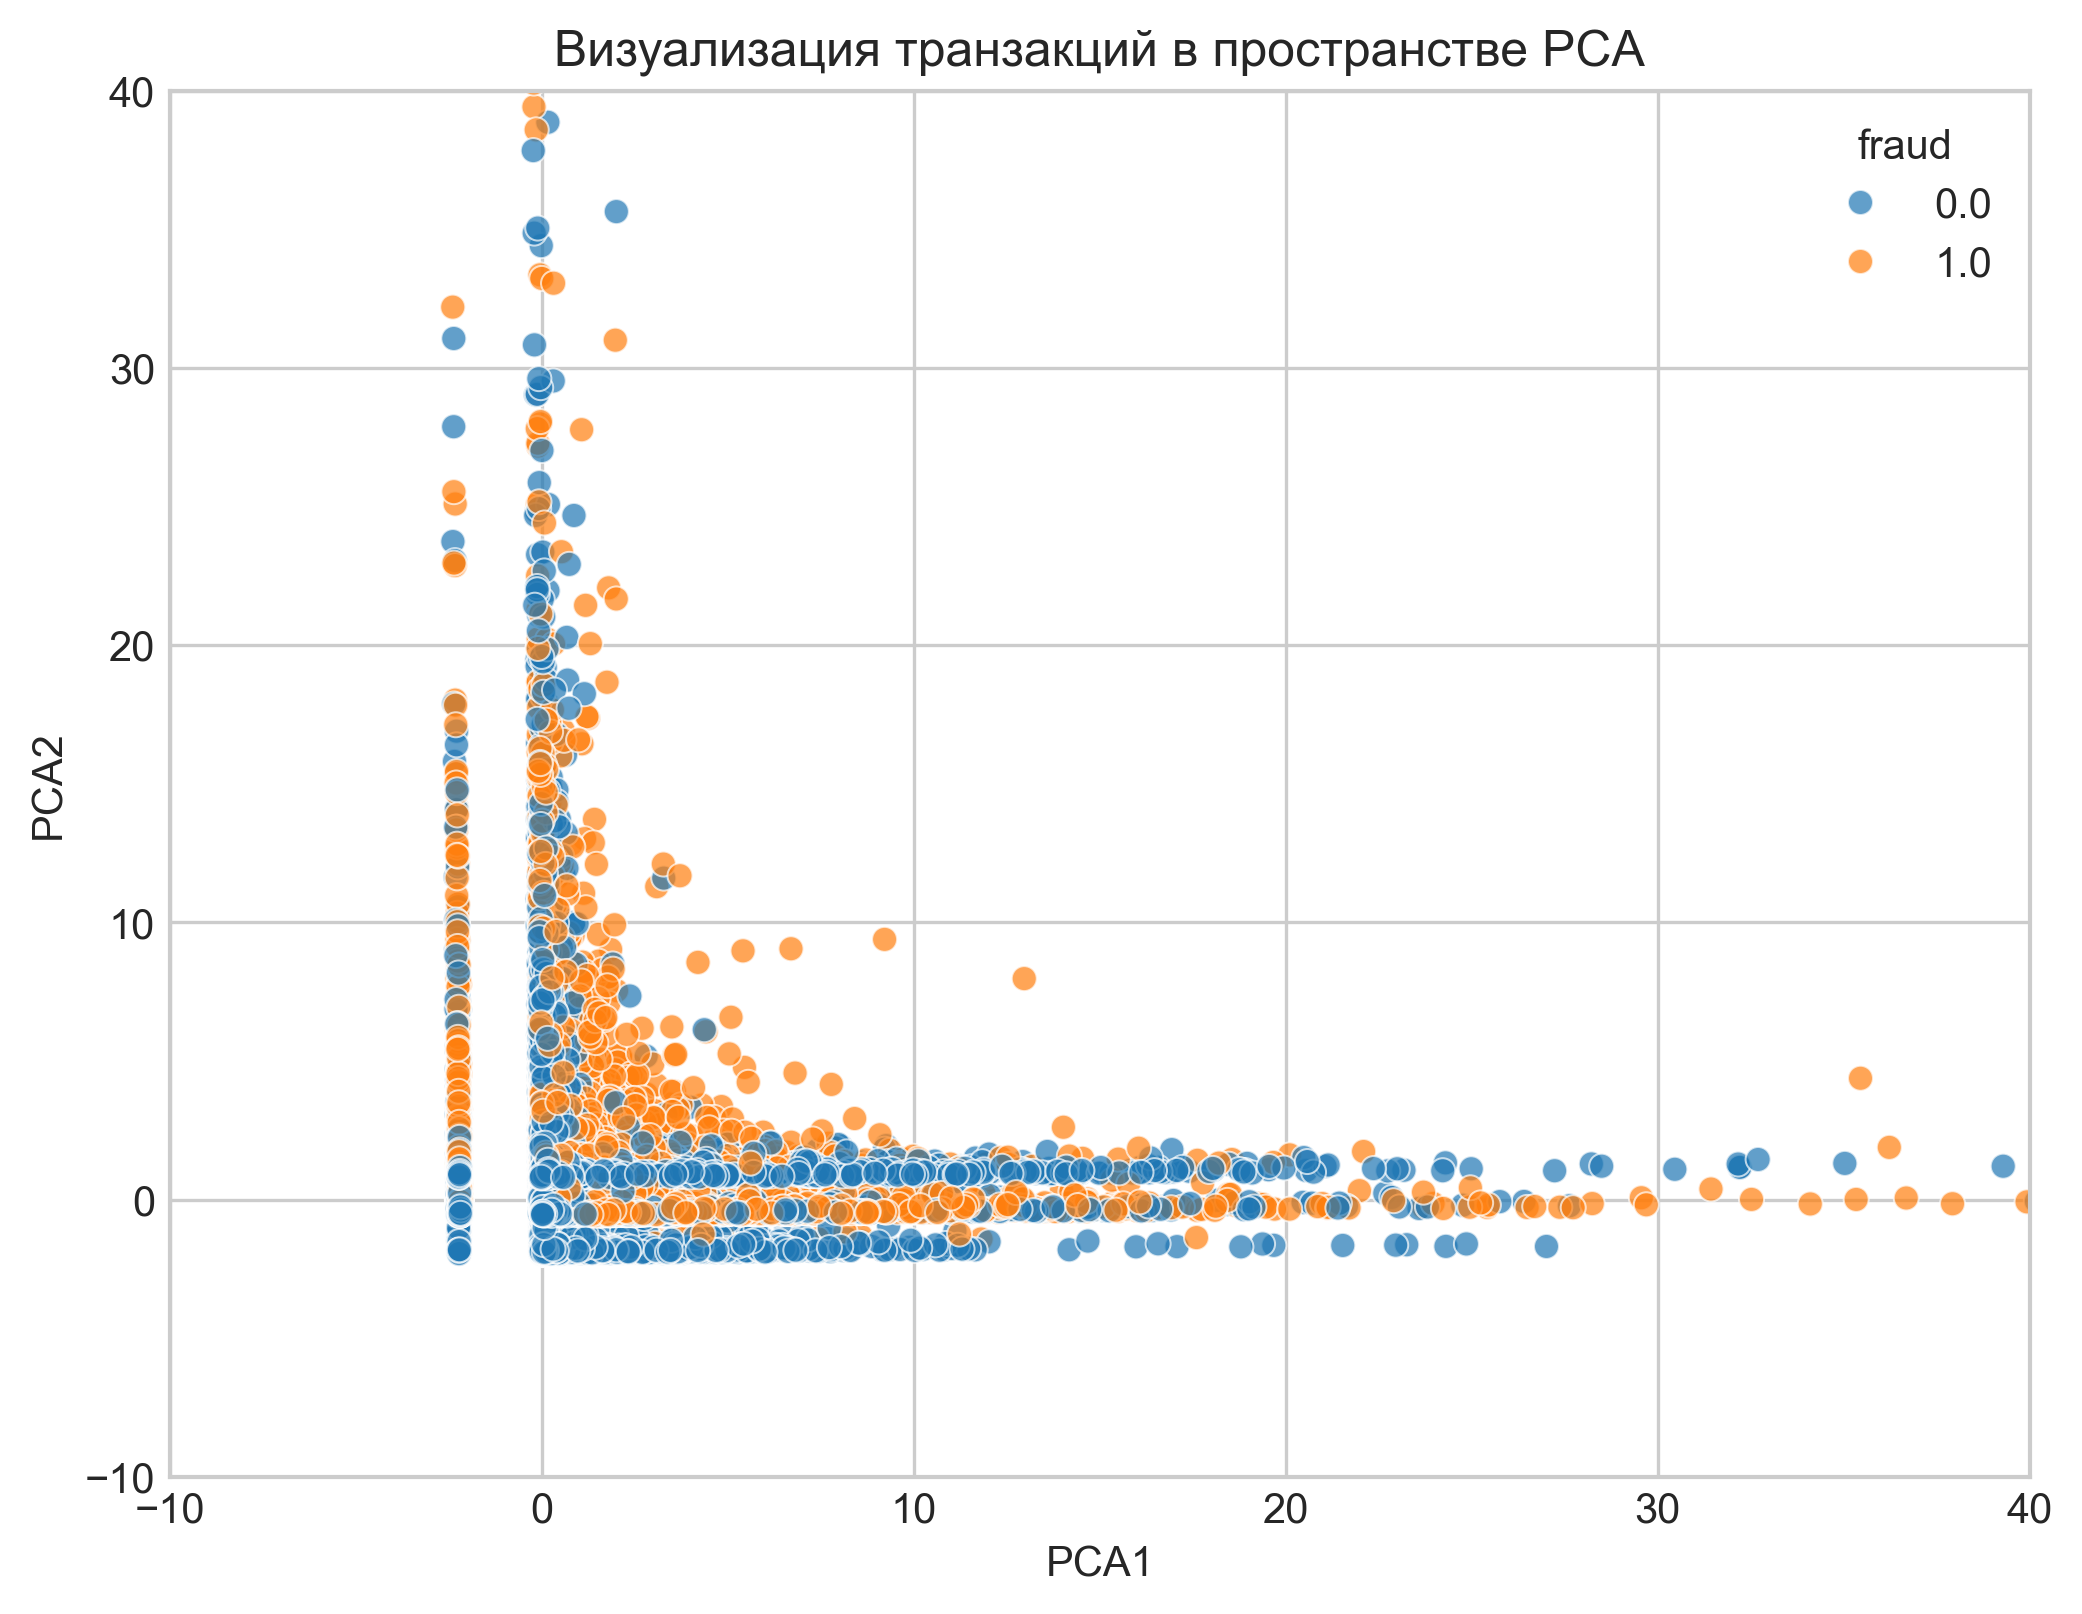

In [217]:
sns.scatterplot(
    data=pca_df,
    x="PCA1",
    y="PCA2",
    hue="fraud",
    alpha=0.7
)

plt.xlim(-10, 40)
plt.ylim(-10, 40)
plt.title("Визуализация транзакций в пространстве PCA")
plt.show()

Визуализация данных методом PCA показала значительное перекрытие классов мошеннических и обычных транзакций в пространстве первых двух главных компонент. Это указывает на отсутствие выраженной линейной разделимости между классами.
При этом в отдельных областях пространства наблюдаются различия в плотности распределения объектов разных классов, что может свидетельствовать о наличии более сложной структуры данных.
Полученные результаты подтверждают необходимость применения нелинейных методов анализа и моделей машинного обучения для решения задачи обнаружения мошенничества.

### Метод стохастического вложения соседей с t-распределением

In [210]:
from openTSNE import TSNE

X_sample = df.drop(columns=["fraud"])

X_scaled = StandardScaler().fit_transform(X_sample)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    n_jobs=-1
)

X_tsne = tsne.fit(X_scaled)

tsne_df = pd.DataFrame({
    "TSNE1": X_tsne[:, 0],
    "TSNE2": X_tsne[:, 1],
    "fraud": sample["fraud"].values
})

In [ ]:
sns.scatterplot(
    data=tsne_df,
    x="TSNE1",
    y="TSNE2",
    hue="fraud",
    alpha=0.6
)

plt.title("Визуализация транзакций t-SNE")
plt.show()

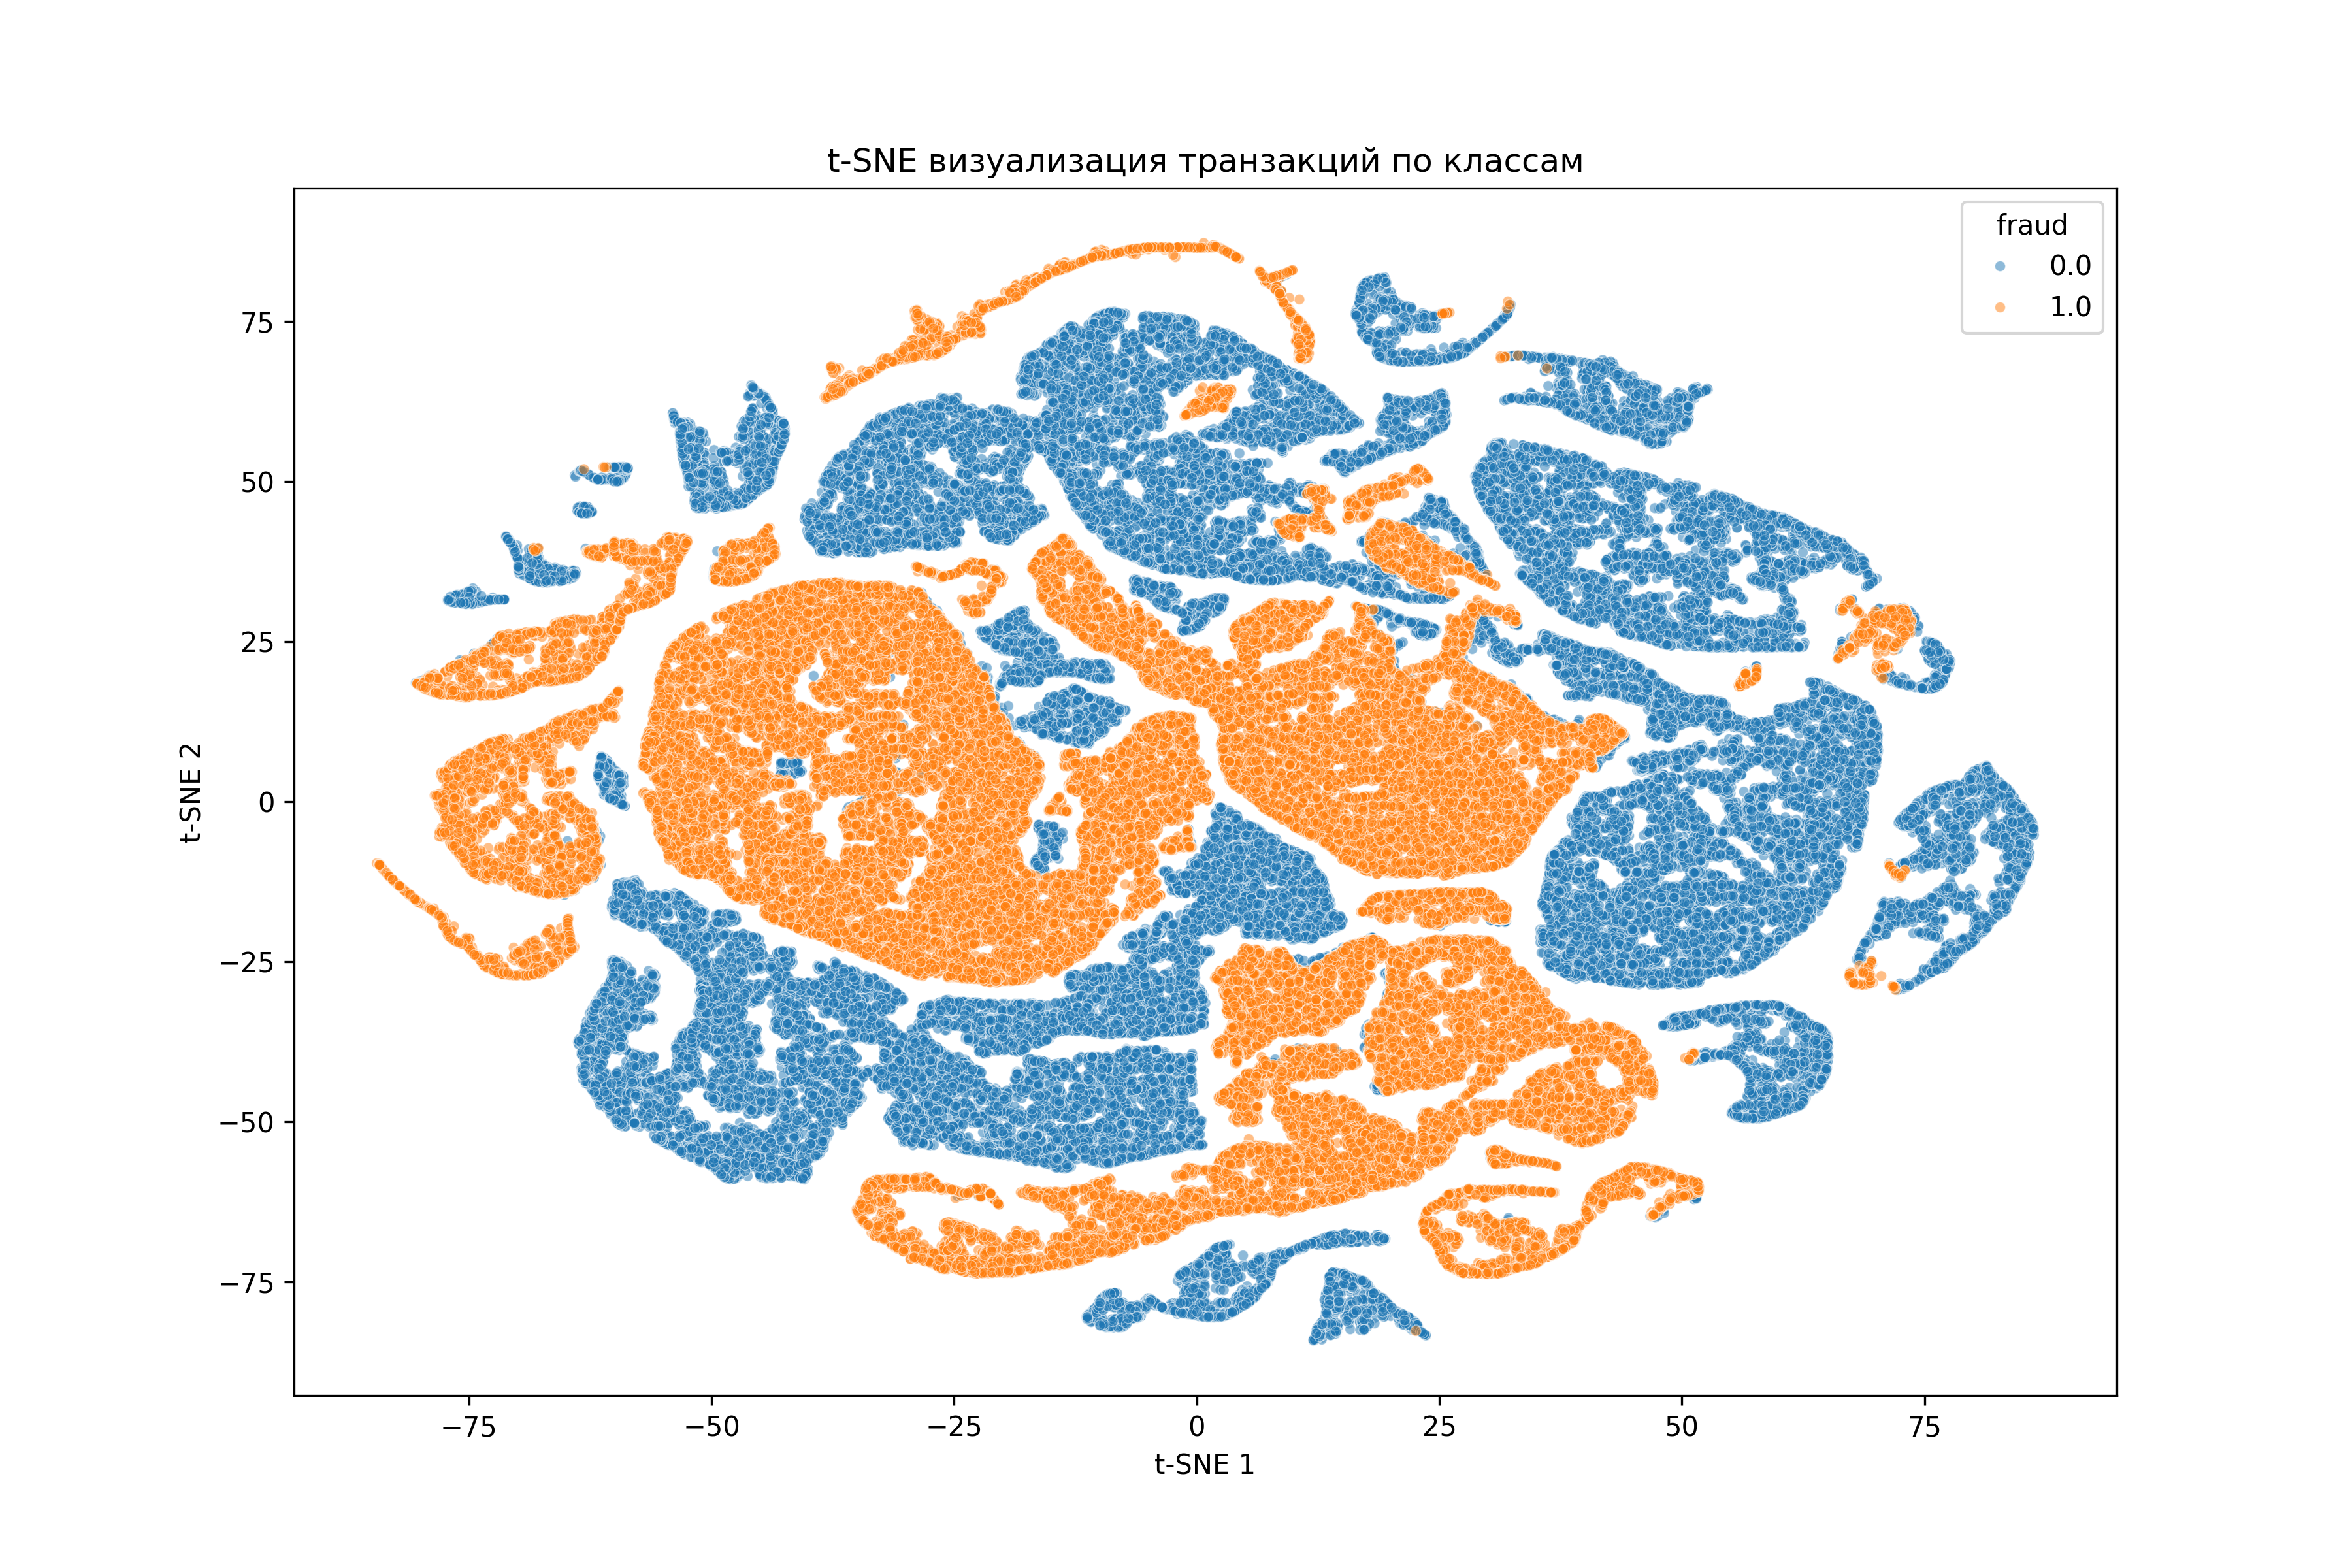

In [216]:
from IPython.display import Image, display

display(Image(filename='t-sne.png'))

t-SNE визуализация показывает наличие локальных областей, в которых преобладают мошеннические или обычные транзакции. Это указывает на существование нелинейной структуры в признаковом пространстве. При этом классы не разделяются полностью, что подтверждает сложность задачи и необходимость применения моделей машинного обучения, способных учитывать нелинейные зависимости между признаками.
Поскольку t-SNE является методом визуализации и чувствителен к параметрам, полученный график следует рассматривать как иллюстративное подтверждение структуры данных, а не как строгую оценку качества разделения классов.

## Анализ разделимости признаков. Вывод

Проведённый анализ разделимости классов показал наличие существенного перекрытия мошеннических и обычных транзакций в признаковом пространстве. Несмотря на существование локальных областей концентрации fraud-операций, классы не обладают выраженной линейной разделимостью. Это подтверждает необходимость применения нелинейных моделей машинного обучения и методов обнаружения аномалий для решения задачи anti-fraud классификации.